# TOW-IDS ML — Automotive Ethernet Intrusion Detection System

Anomaly detection framework for **Automotive Ethernet** networks using GAN-based and deep learning models. This notebook implements, trains, and evaluates multiple unsupervised, semi-supervised, and supervised intrusion detection approaches on real-world automotive traffic captures.

In [1]:
import os
import random
import shlex
import subprocess
import textwrap
import time
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import OneClassSVM

import pynvml
import psutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# === File paths ===
TRAIN_PCAP = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
TEST_PCAP  = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/Automotive_Ethernet_with_Attack_original_10_17_20_04_test.pcap"
OUT_DIR = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/extracted"

y_train_path = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/y_train.csv"
y_test_path  = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/y_test.csv"

# === Defaults ===
WINDOW_SEC = 1.0
T_SEQ = 40
ZDIM = 16
THR_PCT = 99

In [3]:
# =============================================
# Utility Functions (used throughout notebook)
# =============================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_feature_cols(df):
    return [c for c in df.columns if c not in ["w", "y_window", "attack_type_window"]]


def model_size_stats(model):
    params = sum(p.numel() for p in model.parameters())
    bytes_ = sum(p.numel() * p.element_size() for p in model.parameters())
    return {"Params": int(params), "Size (MB)": float(bytes_ / 1024**2)}


def combined_model_size(*models):
    params = 0
    bytes_ = 0
    for m in models:
        params += sum(p.numel() for p in m.parameters())
        bytes_ += sum(p.numel() * p.element_size() for p in m.parameters())
    return {"Params": int(params), "Size (MB)": float(bytes_ / 1024**2)}


def measure_latency_ms(fn, runs=200):
    times = []
    for _ in range(runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times) * 1000)


def repeat_workload(fn, n=200):
    def _wrapped():
        for _ in range(n):
            fn()
    return _wrapped


def measure_peak_cuda_mem_mb(fn):
    if not torch.cuda.is_available():
        return np.nan
    torch.cuda.reset_peak_memory_stats()
    fn()
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**2


def fmt_cols(df, cols, fmt=".4f"):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = df[c].map(lambda x: float(f"{x:{fmt}}") if pd.notna(x) else x)
    return df


def compute_all_metrics(y_true, scores, thr):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)
    y_pred = (scores > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "thr": float(thr),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def compute_metrics_99pct(y_true, scores, train_scores, pct=99):
    thr = float(np.percentile(np.asarray(train_scores, dtype=float), pct))
    return compute_all_metrics(y_true, scores, thr)


def per_attack_breakdown(scores, y_seq, atk_seq):
    df = pd.DataFrame({"score": scores, "y": y_seq.astype(int), "atk": atk_seq.astype(str)})
    attacks = sorted([a for a in df["atk"].unique() if a != "normal"])
    rows = []
    for a in attacks:
        sub = df[df["atk"].isin(["normal", a])]
        if sub["y"].nunique() < 2:
            continue
        roc = roc_auc_score(sub["y"], sub["score"])
        pr = average_precision_score(sub["y"], sub["score"])
        rows.append({"attack": a, "n_attack_seq": int((sub["atk"] == a).sum()),
                      "roc_auc": roc, "pr_auc": pr})
    return pd.DataFrame(rows).sort_values("pr_auc", ascending=False)


def replay_pr_auc(scores, y_seq, atk_seq, replay_label="c_r"):
    df = pd.DataFrame({"score": scores, "y": y_seq.astype(int), "atk": atk_seq.astype(str)})
    sub = df[df["atk"].isin(["normal", replay_label])]
    if sub["y"].nunique() < 2:
        return np.nan
    return average_precision_score(sub["y"].values, sub["score"].values)


def seq_scores_to_window_scores(seq_scores, n_windows, t_seq=40, stride=1, agg="mean"):
    seq_scores = np.asarray(seq_scores, dtype=float)
    n_seq = len(seq_scores)

    if agg == "max":
        out = np.full(n_windows, -np.inf, dtype=float)
        for i in range(n_seq):
            start = i * stride
            end = min(start + t_seq, n_windows)
            out[start:end] = np.maximum(out[start:end], seq_scores[i])
        out[np.isneginf(out)] = 0.0
        return out

    # mean aggregation
    win_scores = np.zeros(n_windows, dtype=float)
    win_counts = np.zeros(n_windows, dtype=float)
    for i in range(n_seq):
        start = i * stride
        end = min(start + t_seq, n_windows)
        if start >= n_windows:
            break
        win_scores[start:end] += seq_scores[i]
        win_counts[start:end] += 1.0

    mask = win_counts > 0
    out = np.zeros(n_windows, dtype=float)
    out[mask] = win_scores[mask] / win_counts[mask]
    return out

## 1. Data Ingestion

In [4]:
os.makedirs(OUT_DIR, exist_ok=True)

train_csv = f"{OUT_DIR}/packets_train.csv"
cmd = f"""
tshark -r {shlex.quote(TRAIN_PCAP)} \\
  -T fields -E header=y -E separator=, -E quote=d \\
  -e frame.number -e frame.time_epoch -e frame.len \\
  -e eth.src -e eth.dst -e eth.type \\
  -e vlan.id -e vlan.etype \\
  -e ip.src -e ip.dst -e ip.proto -e ip.ttl \\
  -e udp.srcport -e udp.dstport -e udp.length \\
  -e udp.payload -e data.data \\
  > {shlex.quote(train_csv)}
"""
subprocess.run(cmd, shell=True, check=True)

test_csv = f"{OUT_DIR}/packets_test.csv"
cmd = f"""
tshark -r {shlex.quote(TEST_PCAP)} \\
  -T fields -E header=y -E separator=, -E quote=d \\
  -e frame.number -e frame.time_epoch -e frame.len \\
  -e eth.src -e eth.dst -e eth.type \\
  -e vlan.id -e vlan.etype \\
  -e ip.src -e ip.dst -e ip.proto -e ip.ttl \\
  -e udp.srcport -e udp.dstport -e udp.length \\
  -e udp.payload -e data.data \\
  > {shlex.quote(test_csv)}
"""
subprocess.run(cmd, shell=True, check=True)

train_pkts = pd.read_csv(train_csv)
test_pkts = pd.read_csv(test_csv)
print("Train shape:", train_pkts.shape)
print("Test  shape:", test_pkts.shape)
train_pkts.head()

Train shape: (1203737, 17)
Test  shape: (791611, 17)


,frame.number,frame.time_epoch,frame.len,eth.src,eth.dst,eth.type,vlan.id,vlan.etype,ip.src,ip.dst,ip.proto,ip.ttl,udp.srcport,udp.dstport,udp.length,udp.payload,data.data
0,1,1.599904e+09,434,00:fc:70:00:00:03,91:ef:00:00:fe:00,0x8100,2.0,0x22f0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1.599904e+09,434,00:fc:70:00:00:03,91:ef:00:00:fe:00,0x8100,2.0,0x22f0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1.599904e+09,434,00:fc:70:00:00:03,91:ef:00:00:fe:00,0x8100,2.0,0x22f0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1.599904e+09,434,00:fc:70:00:00:03,91:ef:00:00:fe:00,0x8100,2.0,0x22f0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1.599904e+09,434,00:fc:70:00:00:03,91:ef:00:00:fe:00,0x8100,2.0,0x22f0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Train EtherTypes (sample):", train_pkts["eth.type"].dropna().unique()[:10])
print("Train VLAN IDs (sample):", train_pkts["vlan.id"].dropna().unique()[:10])
print("Train IP proto (sample):", train_pkts["ip.proto"].dropna().unique()[:10])
print("Has UDP payload:", train_pkts["udp.payload"].notna().mean())
print("Has raw data.data:", train_pkts["data.data"].notna().mean())

Train EtherTypes (sample): ['0x8100' '0x88f7' '0x0800' '0x0806' '0x88f5' '0x22ea' '0x22f0' '0x86dd']
Train VLAN IDs (sample): [2.]
Train IP proto (sample): [17.  0.]
Has UDP payload: 0.669189366115688
Has raw data.data: 0.6693114858145924


In [6]:
# Load labels
y_train = pd.read_csv(y_train_path, header=None)
y_test  = pd.read_csv(y_test_path,  header=None)
y_train.columns = ["sample_number", "normal_or_abnormal", "attack_type"]
y_test.columns  = ["sample_number", "normal_or_abnormal", "attack_type"]

# Merge train labels
train_pkts["frame.number"] = pd.to_numeric(train_pkts["frame.number"], errors="coerce").astype("Int64")
y_train["sample_number"]   = pd.to_numeric(y_train["sample_number"], errors="coerce").astype("Int64")
train_pkts = train_pkts.merge(y_train, left_on="frame.number", right_on="sample_number", how="left").drop(columns=["sample_number"])
train_pkts["y"] = (train_pkts["normal_or_abnormal"].str.lower() == "abnormal").astype(int)

# Merge test labels
test_pkts["frame.number"] = pd.to_numeric(test_pkts["frame.number"], errors="coerce").astype("Int64")
y_test["sample_number"]   = pd.to_numeric(y_test["sample_number"], errors="coerce").astype("Int64")
test_pkts = test_pkts.merge(y_test, left_on="frame.number", right_on="sample_number", how="left").drop(columns=["sample_number"])
test_pkts["y"] = (test_pkts["normal_or_abnormal"].str.lower() == "abnormal").astype(int)

print("Train label distribution:\n", train_pkts["y"].value_counts())
print("Test label distribution:\n", test_pkts["y"].value_counts())

Train label distribution:
 0    954912
1    248825
Name: y, dtype: int64
Test label distribution:
 0    660777
1    130834
Name: y, dtype: int64


In [7]:
# Normalize attack_type across train/test
for df in [train_pkts, test_pkts]:
    df["attack_type"] = None
    for c in ["attack_type_y", "attack_type_x", "attack_type"]:
        if c in df.columns:
            df["attack_type"] = df["attack_type"].fillna(df[c])
    df["attack_type"] = df["attack_type"].astype(str).str.strip().str.lower()

print("Test attack_type top:\n", test_pkts["attack_type"].value_counts().head(15))
print("Train attack_type top:\n", train_pkts["attack_type"].value_counts().head(15))

Test attack_type top:
 none    791611
Name: attack_type, dtype: int64
Train attack_type top:
 none    1203737
Name: attack_type, dtype: int64


## 2. Feature Engineering

In [8]:
def build_global_windows_with_attack(df, window_sec=1.0):
    """Build windowed features with attack-type labels. Definitive version."""
    df = df.copy()
    df["t"] = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t")

    t0 = df["t"].iloc[0]
    df["w"] = np.floor((df["t"] - t0) / window_sec).astype(int)
    df["frame.len"] = pd.to_numeric(df["frame.len"], errors="coerce").fillna(0.0)
    df["dt"] = df["t"].diff().fillna(0.0).clip(lower=0.0)
    df["is_multicast"] = df["eth.dst"].astype(str).str.lower().str.startswith(("01:", "33:")).astype(int)
    df["has_vlan"] = df["vlan.id"].notna().astype(int)

    def agg(g):
        y_win = int(pd.to_numeric(g["y"], errors="coerce").fillna(0).max())
        if y_win == 0:
            atk = "normal"
        else:
            atk_series = g.loc[g["y"] == 1, "attack_type"].astype(str).str.strip()
            atk = atk_series.value_counts().index[0] if len(atk_series) else "anomaly"

        return pd.Series({
            "pkt_count": len(g),
            "bytes_sum": g["frame.len"].sum(),
            "pkt_len_mean": g["frame.len"].mean(),
            "pkt_len_std": g["frame.len"].std(ddof=0),
            "dt_mean": g["dt"].mean(),
            "dt_std": g["dt"].std(ddof=0),
            "uniq_src_mac": g["eth.src"].nunique(dropna=True),
            "uniq_dst_mac": g["eth.dst"].nunique(dropna=True),
            "uniq_ip_src": g["ip.src"].nunique(dropna=True),
            "uniq_ip_dst": g["ip.dst"].nunique(dropna=True),
            "multicast_ratio": g["is_multicast"].mean(),
            "vlan_ratio": g["has_vlan"].mean(),
            "y_window": y_win,
            "attack_type_window": atk,
        })

    return df.groupby("w").apply(agg).reset_index().fillna(0.0)


train_w = build_global_windows_with_attack(train_pkts, window_sec=WINDOW_SEC)
test_w  = build_global_windows_with_attack(test_pkts,  window_sec=WINDOW_SEC)

print("Train windows:", train_w.shape, "\n", train_w["y_window"].value_counts())
print("Test windows:", test_w.shape, "\n", test_w["y_window"].value_counts())
print("Test attack types:\n", test_w.loc[test_w["y_window"]==1, "attack_type_window"].value_counts())

Train windows: (553, 15) 
 1    280
0    273
Name: y_window, dtype: int64
Test windows: (397, 15) 
 0    240
1    157
Name: y_window, dtype: int64
Test attack types:
 none    157
Name: attack_type_window, dtype: int64


In [9]:
def make_sequences(df, t_seq=20, stride=1, feature_cols=None):
    """Build sliding-window sequences for anomaly detection models."""
    df = df.sort_values("w").reset_index(drop=True)
    if feature_cols is None:
        feature_cols = get_feature_cols(df)
    X = df[feature_cols].astype(float).to_numpy()
    y = df["y_window"].astype(int).to_numpy()
    atk = df["attack_type_window"].astype(str).to_numpy() if "attack_type_window" in df.columns else np.array(["normal"] * len(df))

    seqs, seq_y, seq_atk = [], [], []
    for start in range(0, len(df) - t_seq + 1, stride):
        end = start + t_seq
        seqs.append(X[start:end])
        y_s = int(y[start:end].max())
        seq_y.append(y_s)
        if y_s == 0:
            seq_atk.append("normal")
        else:
            anom_types = atk[start:end][y[start:end] == 1]
            seq_atk.append(pd.Series(anom_types).value_counts().index[0] if len(anom_types) else "anomaly")

    return np.stack(seqs), np.array(seq_y), np.array(seq_atk)


def build_nextstep_sequences_from_windows(df_w, t_seq=20, stride=1, feature_cols=None):
    """Build (input_seq, next_window) pairs for next-step prediction models."""
    df = df_w.copy().reset_index(drop=True)
    if feature_cols is None:
        feature_cols = get_feature_cols(df)

    X = df[feature_cols].astype(float).fillna(0.0).values
    y = df["y_window"].astype(int).values
    atk = df["attack_type_window"].astype(str).values if "attack_type_window" in df.columns else None

    N = (len(df) - t_seq - 1) // stride + 1
    D = len(feature_cols)
    X_seq = np.zeros((N, t_seq, D), dtype=np.float32)
    y_next = np.zeros((N, D), dtype=np.float32)
    y_seq = np.zeros((N,), dtype=np.int64)
    atk_seq = np.array(["normal"] * N, dtype=object) if atk is not None else None

    k = 0
    for i in range(0, len(df) - t_seq, stride):
        X_seq[k] = X[i:i+t_seq]
        y_next[k] = X[i+t_seq]
        y_seq[k] = y[i+t_seq]
        if atk is not None:
            atk_seq[k] = atk[i+t_seq]
        k += 1

    return X_seq[:k], y_next[:k], y_seq[:k], atk_seq[:k] if atk_seq is not None else None, feature_cols


def fit_scaler_on_normal(train_w, test_w, scaler_cls=StandardScaler, **scaler_kw):
    """Fit scaler on train-normal windows, transform train-normal and test."""
    feat_cols = get_feature_cols(train_w)
    X_train_norm = train_w.loc[train_w["y_window"]==0, feat_cols].astype(float).fillna(0.0).to_numpy()
    X_test = test_w[feat_cols].astype(float).fillna(0.0).to_numpy()
    y_test = test_w["y_window"].astype(int).to_numpy()

    scaler = scaler_cls(**scaler_kw)
    X_train_s = scaler.fit_transform(X_train_norm)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_test_s, y_test, scaler, feat_cols


def scale_train_test_sequences(Xtr_normal, Xte_all):
    """Fit StandardScaler on normal train sequences, transform both."""
    N, T, D = Xtr_normal.shape
    scaler = StandardScaler()
    scaler.fit(Xtr_normal.reshape(-1, D))

    def scale_seq(X):
        n, t, d = X.shape
        return scaler.transform(X.reshape(-1, d)).reshape(n, t, d)

    return scale_seq(Xtr_normal), scale_seq(Xte_all), scaler


def standardize_seq_and_next(Xtr_seq_norm, ytr_next_norm, Xte_seq, yte_next, feature_dim):
    """Fit scaler on train-normal windows (flattened), then transform X_seq and y_next."""
    scaler = StandardScaler()
    scaler.fit(Xtr_seq_norm.reshape(-1, feature_dim))

    def tx_seq(Xseq):
        return scaler.transform(Xseq.reshape(-1, feature_dim)).reshape(Xseq.shape).astype(np.float32)

    def tx_vec(Y):
        return scaler.transform(Y).astype(np.float32)

    return tx_seq(Xtr_seq_norm), tx_vec(ytr_next_norm), tx_seq(Xte_seq), tx_vec(yte_next), scaler

In [10]:
# =============================================
# Profiling / Energy Measurement Utilities
# =============================================

def nvml_energy_joules(workload_fn, device_index=0, sample_ms=10):
    pynvml.nvmlInit()
    h = pynvml.nvmlDeviceGetHandleByIndex(device_index)

    workload_fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    samples_t, samples_p = [], []
    stop = threading.Event()

    def sampler():
        t0 = time.perf_counter()
        while not stop.is_set():
            t = time.perf_counter() - t0
            p = pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0
            samples_t.append(t)
            samples_p.append(p)
            time.sleep(sample_ms / 1000.0)

    th = threading.Thread(target=sampler, daemon=True)
    th.start()
    t_start = time.perf_counter()
    workload_fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t_start
    stop.set()
    th.join(timeout=1.0)
    pynvml.nvmlShutdown()

    if len(samples_t) >= 2:
        energy_j = float(np.trapz(np.array(samples_p), np.array(samples_t)))
    else:
        energy_j = float(np.mean(samples_p) * elapsed) if samples_p else np.nan
    avg_power = energy_j / elapsed if elapsed > 0 else np.nan
    return energy_j, avg_power, elapsed


def profile_workload(fn, repeats=200, device_index=0, sample_ms=10):
    pynvml.nvmlInit()
    h = pynvml.nvmlDeviceGetHandleByIndex(device_index)
    proc = psutil.Process()
    stop = threading.Event()

    gpu_power_w, gpu_util, gpu_mem_mb, cpu_util, rss_mb, ts = [], [], [], [], [], []

    def sampler():
        t0 = time.perf_counter()
        while not stop.is_set():
            now = time.perf_counter() - t0
            ts.append(now)
            p = pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0
            u = pynvml.nvmlDeviceGetUtilizationRates(h)
            mem = pynvml.nvmlDeviceGetMemoryInfo(h)
            gpu_power_w.append(p)
            gpu_util.append(float(u.gpu))
            gpu_mem_mb.append(mem.used / 1024**2)
            cpu_util.append(psutil.cpu_percent(interval=None))
            rss_mb.append(proc.memory_info().rss / 1024**2)
            time.sleep(sample_ms / 1000.0)

    fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    th = threading.Thread(target=sampler, daemon=True)
    th.start()
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    stop.set()
    th.join(timeout=1.0)
    pynvml.nvmlShutdown()

    energy_j = float(np.trapz(np.array(gpu_power_w), np.array(ts))) if len(ts) >= 2 else (float(np.mean(gpu_power_w) * elapsed) if gpu_power_w else np.nan)

    return {
        "Elapsed (s)": elapsed,
        "Latency (ms)": elapsed * 1000.0 / repeats,
        "Throughput (calls/s)": repeats / elapsed,
        "GPU Power Avg (W)": float(np.mean(gpu_power_w)) if gpu_power_w else np.nan,
        "GPU Power Peak (W)": float(np.max(gpu_power_w)) if gpu_power_w else np.nan,
        "GPU Util Avg (%)": float(np.mean(gpu_util)) if gpu_util else np.nan,
        "GPU Mem Avg (MB)": float(np.mean(gpu_mem_mb)) if gpu_mem_mb else np.nan,
        "GPU Mem Peak (MB)": float(np.max(gpu_mem_mb)) if gpu_mem_mb else np.nan,
        "CPU Util Avg (%)": float(np.mean(cpu_util)) if cpu_util else np.nan,
        "RSS Peak (MB)": float(np.max(rss_mb)) if rss_mb else np.nan,
        "Energy Total (J)": energy_j,
        "Energy (J/call)": energy_j / repeats if np.isfinite(energy_j) else np.nan,
    }

## 3. Exploratory Data Analysis

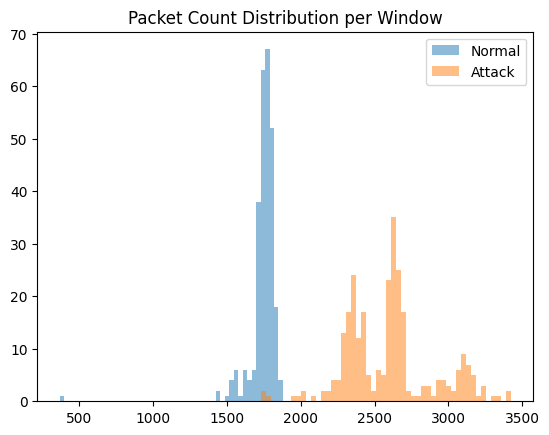

In [11]:
plt.hist(train_w[train_w["y_window"]==0]["pkt_count"], bins=50, alpha=0.5, label="Normal")
plt.hist(train_w[train_w["y_window"]==1]["pkt_count"], bins=50, alpha=0.5, label="Attack")
plt.legend()
plt.title("Packet Count Distribution per Window")
plt.show()

## 4. GANomaly (Window-Level)

**Reference:** Akcay, S., Atapour-Abarghouei, A., & Breckon, T. P. (2018). *GANomaly: Semi-supervised Anomaly Detection via Adversarial Training.* ACCV.

**Architecture:** Encoder-Decoder-Encoder sub-networks within a conditional GAN framework:
- **Encoder** $E$: maps input $\mathbf{x}$ to latent vector $\mathbf{z} = E(\mathbf{x})$
- **Decoder** $D$: reconstructs $\hat{\mathbf{x}} = D(\mathbf{z})$
- **Second Encoder** $E'$: re-encodes the reconstruction $\hat{\mathbf{z}} = E'(\hat{\mathbf{x}})$
- **Discriminator** $C$: classifies real vs. generated

**Training Loss:** $\mathcal{L} = w_{adv} \cdot \mathcal{L}_{adv} + w_{rec} \cdot \mathcal{L}_{rec} + w_{enc} \cdot \mathcal{L}_{enc}$
- $\mathcal{L}_{adv}$: adversarial loss (BCE between discriminator outputs)
- $\mathcal{L}_{rec}$: reconstruction loss $\|\mathbf{x} - \hat{\mathbf{x}}\|_1$
- $\mathcal{L}_{enc}$: encoding loss $\|\mathbf{z} - \hat{\mathbf{z}}\|_2$

**Anomaly Score:** $A(\mathbf{x}) = \|E(\mathbf{x}) - E'(D(E(\mathbf{x})))\|_1$ — the distance in latent space between the original encoding and the re-encoding of the reconstruction. Normal samples produce small distances (model reconstructs well); anomalies produce large distances.

**Key Insight:** Trained on **normal data only** (unsupervised). Operates at **window level** — each 1-second time window is scored independently.

In [12]:
def train_and_eval_ganomaly(train_w, test_w, *,
                            latent_dim=4, hidden=32, batch_size=32,
                            epochs=200, lr=1e-4,
                            lambda_rec=100, lambda_lat=1, lambda_adv=1,
                            alpha=0.7, thr_percentile=99, seed=42):
    set_seed(seed)

    train_normal = train_w[train_w["y_window"] == 0].copy()
    test_all = test_w.copy()
    feature_cols = get_feature_cols(train_normal)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_normal[feature_cols].astype(float).fillna(0.0))
    X_test  = scaler.transform(test_all[feature_cols].astype(float).fillna(0.0))
    y_test  = test_all["y_window"].astype(int).values

    input_dim = X_train.shape[1]

    class Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU(), nn.Linear(hidden, latent_dim))
        def forward(self, x): return self.net(x)

    class Decoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(latent_dim, hidden), nn.ReLU(), nn.Linear(hidden, input_dim))
        def forward(self, z): return self.net(z)

    class Discriminator(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1))
        def forward(self, x): return self.net(x)

    enc, dec, disc = Encoder().to(device), Decoder().to(device), Discriminator().to(device)
    opt_G = optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=lr)
    opt_C = optim.Adam(disc.parameters(), lr=lr)
    criterion_adv = nn.BCEWithLogitsLoss()
    criterion_rec = nn.L1Loss()
    criterion_lat = nn.MSELoss()

    loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=True)

    for _ in range(epochs):
        for (x,) in loader:
            x = x.to(device)
            z = enc(x); x_hat = dec(z)
            real_logits = disc(x); fake_logits = disc(x_hat.detach())
            loss_C = criterion_adv(real_logits, torch.ones_like(real_logits)) + criterion_adv(fake_logits, torch.zeros_like(fake_logits))
            opt_C.zero_grad(); loss_C.backward(); opt_C.step()

            z = enc(x); x_hat = dec(z); z_hat = enc(x_hat)
            loss_G = lambda_adv * criterion_adv(disc(x_hat), torch.ones_like(real_logits)) + lambda_rec * criterion_rec(x_hat, x) + lambda_lat * criterion_lat(z_hat, z)
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    def compute_scores(X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            z = enc(X_t); x_hat = dec(z); z_hat = enc(x_hat)
            rec = torch.mean(torch.abs(x_hat - X_t), dim=1)
            lat = torch.mean((z_hat - z)**2, dim=1)
            s = alpha * rec + (1 - alpha) * lat
        return s.detach().cpu().numpy()

    train_scores = compute_scores(X_train)
    thr = np.percentile(train_scores, thr_percentile)
    test_scores = compute_scores(X_test)

    return {
        **compute_all_metrics(y_test, test_scores, thr),
        "n_train_windows": len(train_w),
        "n_train_normal": int((train_w["y_window"] == 0).sum()),
        "n_test_windows": len(test_w),
        "n_test_anom": int((test_w["y_window"] == 1).sum()),
    }, enc, dec, disc, scaler, feature_cols

In [13]:
window_sizes = [2.0, 1.0, 0.5, 0.2, 0.1]
results = []
for ws in window_sizes:
    tw = build_global_windows_with_attack(train_pkts, window_sec=ws)
    tew = build_global_windows_with_attack(test_pkts, window_sec=ws)
    r, *_ = train_and_eval_ganomaly(tw, tew, seed=42)
    r["window_sec"] = ws
    results.append(r)
    print(f"{ws}s  ROC={r['roc_auc']:.4f}  PR={r['pr_auc']:.4f}  F1={r['f1']:.4f}")

df_res = pd.DataFrame(results).sort_values("window_sec", ascending=False)
df_res[["window_sec","n_train_windows","n_test_windows","roc_auc","pr_auc","precision","recall","f1"]]

2.0s  ROC=0.9892  PR=0.9796  F1=0.9630
1.0s  ROC=0.9913  PR=0.9806  F1=0.9779
0.5s  ROC=0.9904  PR=0.9788  F1=0.9527
0.2s  ROC=0.9732  PR=0.9448  F1=0.7557
0.1s  ROC=0.9320  PR=0.9160  F1=0.8509


,window_sec,n_train_windows,n_test_windows,roc_auc,pr_auc,precision,recall,f1
0,2.0,277,199,0.989181,0.979559,0.951220,0.975000,0.962963
1,1.0,553,397,0.991269,0.980580,0.968750,0.987261,0.977918
2,0.5,1105,794,0.990398,0.978796,0.960526,0.944984,0.952692
3,0.2,2762,1984,0.973151,0.944769,0.950593,0.627119,0.755695
4,0.1,5523,3967,0.931970,0.915980,0.957447,0.765707,0.850909


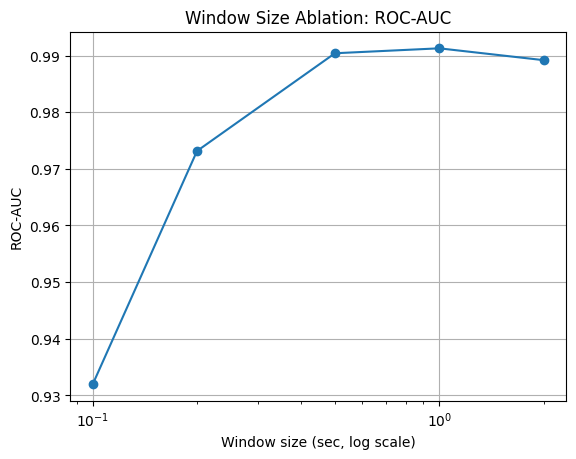

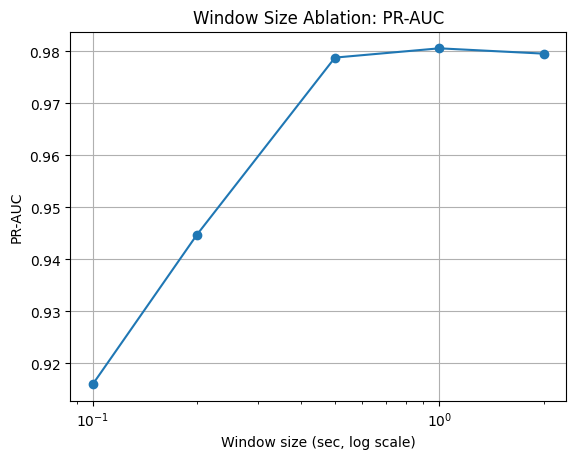

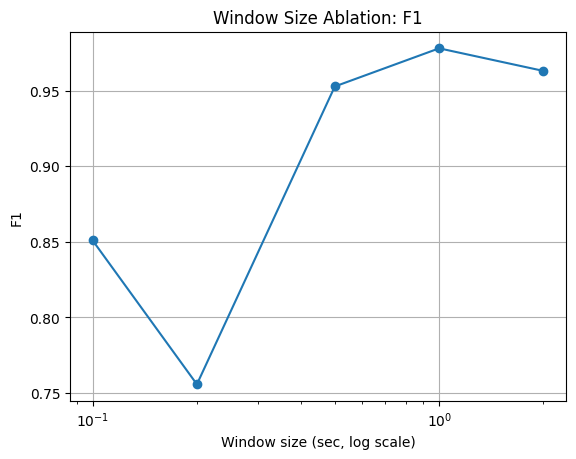

In [14]:
for metric, label in [("roc_auc","ROC-AUC"), ("pr_auc","PR-AUC"), ("f1","F1")]:
    plt.figure()
    plt.plot(df_res["window_sec"], df_res[metric], marker="o")
    plt.xscale("log")
    plt.xlabel("Window size (sec, log scale)")
    plt.ylabel(label)
    plt.title(f"Window Size Ablation: {label}")
    plt.grid(True)
    plt.show()

In [15]:
seeds = [0, 1, 2]
window_sizes_ms = [1.0, 0.5, 0.2, 0.1]
rows = []
for ws in window_sizes_ms:
    tw = build_global_windows_with_attack(train_pkts, ws)
    tew = build_global_windows_with_attack(test_pkts, ws)
    for sd in seeds:
        r, *_ = train_and_eval_ganomaly(tw, tew, seed=sd)
        r["window_sec"] = ws
        r["seed"] = sd
        rows.append(r)

df_ms = pd.DataFrame(rows)
summary = df_ms.groupby("window_sec")[["roc_auc","pr_auc","f1"]].agg(["mean","std"])
summary

roc_auc              pr_auc                  f1          
                mean       std      mean       std      mean       std
window_sec                                                            
0.1         0.910899  0.004558  0.875969  0.013306  0.694862  0.062597
0.2         0.958361  0.016058  0.923024  0.018313  0.640808  0.024773
0.5         0.985144  0.004282  0.965898  0.010371  0.919881  0.041695
1.0         0.989632  0.001756  0.974525  0.007678  0.974481  0.011650

In [16]:
# Train final GANomaly on 1s windows
gan_result, Enc_gan, Dec_gan, C_gan, gan_scaler, gan_feat_cols = train_and_eval_ganomaly(
    train_w, test_w, seed=42
)
print("GANomaly metrics:", {k: f"{v:.4f}" if isinstance(v, float) else v for k, v in gan_result.items()})

# GANomaly scoring helper (reused later)
def ganomaly_scores_windows(enc_gan, dec_gan, X_win_s, batch=4096):
    enc_gan.eval(); dec_gan.eval()
    dev = next(enc_gan.parameters()).device
    scores = []
    with torch.no_grad():
        for i in range(0, len(X_win_s), batch):
            xb = torch.tensor(X_win_s[i:i+batch], dtype=torch.float32, device=dev)
            z = enc_gan(xb); xhat = dec_gan(z); zhat = enc_gan(xhat)
            s = torch.mean(torch.abs(zhat - z), dim=1)
            scores.append(s.detach().cpu().numpy())
    return np.concatenate(scores, axis=0)

gan_summary = pd.DataFrame([
    {"model": "GANomaly", "eval_level": "window", **gan_result}])

fmt_cols(gan_summary, ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"])

GANomaly metrics: {'roc_auc': '0.9913', 'pr_auc': '0.9806', 'thr': '0.8381', 'accuracy': '0.9824', 'precision': '0.9688', 'recall': '0.9873', 'f1': '0.9779', 'TN': 235, 'FP': 5, 'FN': 2, 'TP': 155, 'n_train_windows': 553, 'n_train_normal': 273, 'n_test_windows': 397, 'n_test_anom': 157}


,model,eval_level,roc_auc,pr_auc,thr,accuracy,precision,recall,f1,TN,FP,FN,TP,n_train_windows,n_train_normal,n_test_windows,n_test_anom
0,GANomaly,window,0.9913,0.9806,0.838123,0.9824,0.9688,0.9873,0.9779,235,5,2,155,553,273,397,157


In [17]:
# Per-attack breakdown for GANomaly
X_test_gan = gan_scaler.transform(test_w[gan_feat_cols].astype(float).fillna(0.0))
X_train_gan = gan_scaler.transform(train_w.loc[train_w["y_window"]==0, gan_feat_cols].astype(float).fillna(0.0))

gan_scores = ganomaly_scores_windows(Enc_gan, Dec_gan, X_test_gan)
gan_scores_tr = ganomaly_scores_windows(Enc_gan, Dec_gan, X_train_gan)
thr_gan = np.percentile(gan_scores_tr, THR_PCT)

pa_df = pd.DataFrame({
    "score": gan_scores,
    "y": test_w["y_window"].astype(int).values,
    "attack_type": test_w["attack_type_window"].astype(str).values
})
attack_list = sorted([a for a in pa_df["attack_type"].unique() if a != "normal"])
pa_rows = []
for atk in attack_list:
    subset = pa_df[pa_df["attack_type"].isin(["normal", atk])]
    if subset["y"].nunique() < 2:
        continue
    y_pred = (subset["score"].values > thr_gan).astype(int)
    pa_rows.append({
        "attack_type": atk,
        "n_attack_windows": int((subset["attack_type"] == atk).sum()),
        "roc_auc": roc_auc_score(subset["y"], subset["score"]),
        "pr_auc": average_precision_score(subset["y"], subset["score"]),
        "f1@thr": f1_score(subset["y"].values, y_pred)
    })
pd.DataFrame(pa_rows).sort_values("roc_auc", ascending=False)

,attack_type,n_attack_windows,roc_auc,pr_auc,f1@thr
0,none,157,0.994851,0.990179,0.948328


===== GANomaly Confusion Matrix (Window-Level) =====
TN=224  FP=16  FN=1  TP=156
Precision: 0.9070
Recall:    0.9936
F1:        0.9483


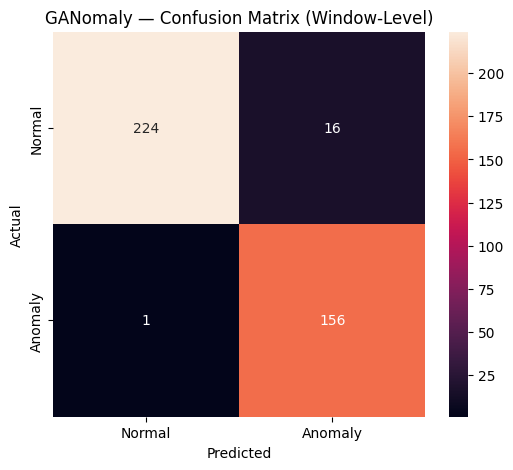

In [18]:
# =============================================
# GANomaly Confusion Matrix
# =============================================

y_true_gan = test_w["y_window"].astype(int).values
y_pred_gan = (gan_scores > thr_gan).astype(int)

cm_gan = confusion_matrix(y_true_gan, y_pred_gan)
tn, fp, fn, tp = cm_gan.ravel()

print("===== GANomaly Confusion Matrix (Window-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(y_true_gan, y_pred_gan):.4f}")
print(f"Recall:    {recall_score(y_true_gan, y_pred_gan):.4f}")
print(f"F1:        {f1_score(y_true_gan, y_pred_gan):.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gan, annot=True, fmt="d", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("GANomaly — Confusion Matrix (Window-Level)")
plt.show()

## 5. GIDS — GAN-based Intrusion Detection System (Window-Level)

**Reference:** Seo, E., Song, H. M., & Kim, H. K. (2018). *GIDS: GAN based Intrusion Detection System for In-Vehicle Network.* IEEE PPSC.

**Original approach:** Designed for CAN bus networks. Converts CAN IDs to one-hot vector images, uses a two-stage GAN architecture with DNN-based Generator and Discriminators.

**Two-Stage Architecture:**
- **1st Discriminator (supervised):** Trained on labeled normal + known attack data. Learns to classify known attack patterns. 3-layer DNN with ReLU activations and Sigmoid output.
- **2nd Discriminator (unsupervised):** Trained via standard GAN adversarial process using **only normal data** + generator fakes. The generator (5-layer DNN with ReLU + Tanh) produces fake samples from random noise. The discriminator learns to distinguish real normal from fake — at inference, real attacks also appear "fake" to this discriminator.

**Detection Flow (Fig. 4 in paper):**
1. Input passes through 1st Discriminator → if output < threshold (0.1), flag as **known attack**
2. If 1st Discriminator says normal → pass to 2nd Discriminator → if output < threshold, flag as **unknown attack**

**Our adaptation for Automotive Ethernet:**
- Input: 12-dimensional windowed statistical features (1-second windows) instead of CAN ID images
- Generator: 5-layer DNN (matching paper's deconvolutional generator adapted to 1D features)
- Both discriminators: 3-layer DNN with ReLU + Sigmoid (matching paper architecture)
- Detection threshold: 0.1 (as specified in paper Section IV-D)

**Key Insight:** Combines supervised detection of known attacks with unsupervised detection of unknown/novel attacks. The paper reported ~98% average accuracy on the 2nd discriminator for four unknown attack types on a Hyundai YF Sonata.

In [19]:
# =============================================
# GIDS Model Definition (adapted for Automotive Ethernet)
# =============================================

class GIDS_Generator(nn.Module):
    """
    Generator: noise (zdim) -> fake window feature vector (input_dim).
    Mirrors the paper's deconvolutional generator but uses DNN
    since our input is a 1D feature vector, not a 2D image.
    """
    def __init__(self, zdim, input_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(zdim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden * 2),
            nn.ReLU(),
            nn.Linear(hidden * 2, hidden * 2),
            nn.ReLU(),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, input_dim),
            nn.Tanh()  # matches paper: Tanh on last layer of generator
        )

    def forward(self, z):
        return self.net(z)


class GIDS_Discriminator(nn.Module):
    """
    Discriminator: window feature vector (input_dim) -> [0, 1].
    3-layer DNN with ReLU + Sigmoid (matching paper architecture).
    Used for both the 1st (supervised) and 2nd (unsupervised) discriminators.
    """
    def __init__(self, input_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
            nn.Sigmoid()  # matches paper: Sigmoid on last layer
        )

    def forward(self, x):
        return self.net(x)


print("GIDS model classes defined.")

GIDS model classes defined.


In [20]:
# =============================================
# Training Functions
# =============================================

def train_gids_second_discriminator(X_train_normal, *, zdim=32, hidden=128,
                                     epochs=200, batch_size=64, lr=2e-4, seed=42):
    """
    Train the 2nd discriminator (unsupervised) via GAN adversarial process.
    Only normal data is used — the generator creates fake samples,
    and the discriminator learns to distinguish real normal from fake.
    """
    set_seed(seed)
    input_dim = X_train_normal.shape[1]

    G = GIDS_Generator(zdim, input_dim, hidden=hidden).to(device)
    D2 = GIDS_Discriminator(input_dim, hidden=hidden).to(device)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D2.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    dataset = TensorDataset(torch.tensor(X_train_normal, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    for ep in range(epochs):
        g_losses, d_losses = [], []
        for (x_real,) in loader:
            x_real = x_real.to(device)
            B = x_real.size(0)
            real_labels = torch.ones(B, 1, device=device)
            fake_labels = torch.zeros(B, 1, device=device)

            # --- Train Discriminator ---
            z = torch.randn(B, zdim, device=device)
            x_fake = G(z).detach()

            d_real = D2(x_real)
            d_fake = D2(x_fake)
            loss_D = bce(d_real, real_labels) + bce(d_fake, fake_labels)

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- Train Generator ---
            z = torch.randn(B, zdim, device=device)
            x_fake = G(z)
            d_fake = D2(x_fake)
            loss_G = bce(d_fake, real_labels)  # generator wants D to say "real"

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            d_losses.append(loss_D.item())
            g_losses.append(loss_G.item())

        if ep % 40 == 0 or ep == epochs - 1:
            print(f"[GIDS-2nd-D] epoch {ep}: D_loss={np.mean(d_losses):.4f}  G_loss={np.mean(g_losses):.4f}")

    return G, D2


def train_gids_first_discriminator(X_normal, X_attack, *, hidden=128,
                                    epochs=100, batch_size=64, lr=1e-3, seed=42):
    """
    Train the 1st discriminator (supervised) on labeled normal + attack data.
    """
    set_seed(seed)
    input_dim = X_normal.shape[1]

    D1 = GIDS_Discriminator(input_dim, hidden=hidden).to(device)
    opt = optim.Adam(D1.parameters(), lr=lr)
    bce = nn.BCELoss()

    X_all = np.vstack([X_normal, X_attack])
    y_all = np.concatenate([np.ones(len(X_normal)), np.zeros(len(X_attack))])  # 1=normal, 0=attack

    dataset = TensorDataset(
        torch.tensor(X_all, dtype=torch.float32),
        torch.tensor(y_all, dtype=torch.float32).unsqueeze(1)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    for ep in range(epochs):
        losses = []
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            out = D1(x_batch)
            loss = bce(out, y_batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        if ep % 20 == 0 or ep == epochs - 1:
            print(f"[GIDS-1st-D] epoch {ep}: loss={np.mean(losses):.4f}")

    return D1


print("GIDS training functions defined.")

GIDS training functions defined.


In [21]:
# =============================================
# GIDS Scoring & Two-Stage Detection
# =============================================

def gids_score(D, X, invert=True):
    """
    Score samples using a GIDS discriminator.
    D outputs ~1 for normal, ~0 for anomalous.
    Anomaly score = 1 - D(x) so higher = more anomalous.
    """
    D.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        out = D(X_t).squeeze(1).cpu().numpy()
    return 1.0 - out if invert else out


def gids_two_stage_score(D1, D2, X, detection_threshold=0.1):
    """
    Two-stage GIDS detection (matching paper's inference flow):
    1. Pass through 1st discriminator — if output < threshold, flag as anomaly
    2. Otherwise pass to 2nd discriminator — if output < threshold, flag as anomaly

    Returns anomaly scores (higher = more anomalous) for evaluation.
    The combined score uses D1 first; if D1 says normal, D2's score is used.
    """
    D1.eval(); D2.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    with torch.no_grad():
        d1_out = D1(X_t).squeeze(1).cpu().numpy()  # ~1 = normal, ~0 = attack
        d2_out = D2(X_t).squeeze(1).cpu().numpy()

    # Combined score: use D1 score if D1 detects anomaly, else use D2 score
    # Both are inverted: higher = more anomalous
    d1_score = 1.0 - d1_out
    d2_score = 1.0 - d2_out

    # If D1 flags it (d1_out < threshold), use d1_score; otherwise use d2_score
    combined = np.where(d1_out < detection_threshold, d1_score, d2_score)
    return combined, d1_score, d2_score


print("GIDS scoring functions defined.")

GIDS scoring functions defined.


In [22]:
# =============================================
# Prepare Data & Train GIDS
# =============================================

# Scale features (fit on train-normal windows)
feat_cols_gids = get_feature_cols(train_w)

X_train_all = train_w[feat_cols_gids].astype(float).fillna(0.0).to_numpy()
y_train_all = train_w["y_window"].astype(int).to_numpy()
X_test_all = test_w[feat_cols_gids].astype(float).fillna(0.0).to_numpy()
y_test_all = test_w["y_window"].astype(int).to_numpy()

scaler_gids = StandardScaler()
X_train_normal = X_train_all[y_train_all == 0]
X_train_attack = X_train_all[y_train_all == 1]

scaler_gids.fit(X_train_normal)
X_train_normal_s = scaler_gids.transform(X_train_normal)
X_train_attack_s = scaler_gids.transform(X_train_attack)
X_test_s_gids = scaler_gids.transform(X_test_all)

print(f"Train normal windows: {len(X_train_normal_s)}")
print(f"Train attack windows: {len(X_train_attack_s)}")
print(f"Test windows: {len(X_test_s_gids)}")

# --- Train 1st Discriminator (supervised: normal + attack) ---
print("\n--- Training 1st Discriminator (supervised) ---")
D1_gids = train_gids_first_discriminator(
    X_train_normal_s, X_train_attack_s,
    hidden=128, epochs=100, batch_size=64, lr=1e-3, seed=42
)

# --- Train 2nd Discriminator (unsupervised GAN: normal only) ---
print("\n--- Training 2nd Discriminator (unsupervised GAN) ---")
G_gids, D2_gids = train_gids_second_discriminator(
    X_train_normal_s,
    zdim=32, hidden=128, epochs=200, batch_size=64, lr=2e-4, seed=42
)

Train normal windows: 273
Train attack windows: 280
Test windows: 397

--- Training 1st Discriminator (supervised) ---
[GIDS-1st-D] epoch 0: loss=0.4180
[GIDS-1st-D] epoch 20: loss=0.0134
[GIDS-1st-D] epoch 40: loss=0.0051
[GIDS-1st-D] epoch 60: loss=0.0024
[GIDS-1st-D] epoch 80: loss=0.0012
[GIDS-1st-D] epoch 99: loss=0.0008

--- Training 2nd Discriminator (unsupervised GAN) ---
[GIDS-2nd-D] epoch 0: D_loss=1.3808  G_loss=0.6801
[GIDS-2nd-D] epoch 40: D_loss=1.3044  G_loss=0.7347
[GIDS-2nd-D] epoch 80: D_loss=1.2835  G_loss=0.6501
[GIDS-2nd-D] epoch 120: D_loss=0.8504  G_loss=1.4050
[GIDS-2nd-D] epoch 160: D_loss=1.2877  G_loss=0.7738
[GIDS-2nd-D] epoch 199: D_loss=1.2057  G_loss=0.6917


In [23]:
# =============================================
# Evaluate GIDS: Individual Discriminators
# =============================================

# --- 1st Discriminator (supervised) ---
d1_scores_tr = gids_score(D1_gids, X_train_normal_s)
d1_scores_te = gids_score(D1_gids, X_test_s_gids)
d1_metrics = compute_metrics_99pct(y_test_all, d1_scores_te, d1_scores_tr)
print("GIDS 1st Discriminator (supervised):")
print({k: f"{v:.4f}" if isinstance(v, float) else v for k, v in d1_metrics.items()})

# --- 2nd Discriminator (unsupervised) ---
d2_scores_tr = gids_score(D2_gids, X_train_normal_s)
d2_scores_te = gids_score(D2_gids, X_test_s_gids)
d2_metrics = compute_metrics_99pct(y_test_all, d2_scores_te, d2_scores_tr)
print("\nGIDS 2nd Discriminator (unsupervised/GAN):")
print({k: f"{v:.4f}" if isinstance(v, float) else v for k, v in d2_metrics.items()})

# --- Two-Stage Combined (paper's full GIDS approach) ---
combined_scores, _, _ = gids_two_stage_score(D1_gids, D2_gids, X_test_s_gids, detection_threshold=0.1)
# For threshold: score the train-normal through both stages
combined_tr, _, _ = gids_two_stage_score(D1_gids, D2_gids, X_train_normal_s, detection_threshold=0.1)
combined_metrics = compute_metrics_99pct(y_test_all, combined_scores, combined_tr)
print("\nGIDS Two-Stage Combined:")
print({k: f"{v:.4f}" if isinstance(v, float) else v for k, v in combined_metrics.items()})

# Summary table
gids_summary = pd.DataFrame([
    {"model": "GIDS 1st-D (supervised)", "eval_level": "window", **d1_metrics},
    {"model": "GIDS 2nd-D (unsupervised)", "eval_level": "window", **d2_metrics},
    {"model": "GIDS Combined (two-stage)", "eval_level": "window", **combined_metrics},
])
fmt_cols(gids_summary, ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"])

GIDS 1st Discriminator (supervised):
{'roc_auc': '0.9939', 'pr_auc': '0.9959', 'thr': '0.0193', 'accuracy': '0.9773', 'precision': '0.9568', 'recall': '0.9873', 'f1': '0.9718', 'TN': 233, 'FP': 7, 'FN': 2, 'TP': 155}

GIDS 2nd Discriminator (unsupervised/GAN):
{'roc_auc': '0.1357', 'pr_auc': '0.3617', 'thr': '0.6619', 'accuracy': '0.6448', 'precision': '0.8077', 'recall': '0.1338', 'f1': '0.2295', 'TN': 235, 'FP': 5, 'FN': 136, 'TP': 21}

GIDS Two-Stage Combined:
{'roc_auc': '0.9756', 'pr_auc': '0.9848', 'thr': '0.6619', 'accuracy': '0.9773', 'precision': '0.9684', 'recall': '0.9745', 'f1': '0.9714', 'TN': 235, 'FP': 5, 'FN': 4, 'TP': 153}


,model,eval_level,roc_auc,pr_auc,thr,accuracy,precision,recall,f1,TN,FP,FN,TP
0,GIDS 1st-D (supervised),window,0.9939,0.9959,0.019258,0.9773,0.9568,0.9873,0.9718,233,7,2,155
1,GIDS 2nd-D (unsupervised),window,0.1357,0.3617,0.661939,0.6448,0.8077,0.1338,0.2295,235,5,136,21
2,GIDS Combined (two-stage),window,0.9756,0.9848,0.661939,0.9773,0.9684,0.9745,0.9714,235,5,4,153


In [24]:
# =============================================
# GIDS Per-Attack Breakdown
# =============================================

atk_types_test = test_w["attack_type_window"].astype(str).values

# Per-attack for each GIDS variant
for name, scores in [("GIDS 1st-D", d1_scores_te),
                      ("GIDS 2nd-D", d2_scores_te),
                      ("GIDS Combined", combined_scores)]:
    pa = per_attack_breakdown(scores, y_test_all, atk_types_test)
    print(f"\n--- {name} Per-Attack ---")
    display(fmt_cols(pa, ["roc_auc", "pr_auc"]))


--- GIDS 1st-D Per-Attack ---


,attack,n_attack_seq,roc_auc,pr_auc
0,none,157,0.9939,0.9959



--- GIDS 2nd-D Per-Attack ---


,attack,n_attack_seq,roc_auc,pr_auc
0,none,157,0.1357,0.3617



--- GIDS Combined Per-Attack ---


,attack,n_attack_seq,roc_auc,pr_auc
0,none,157,0.9756,0.9848


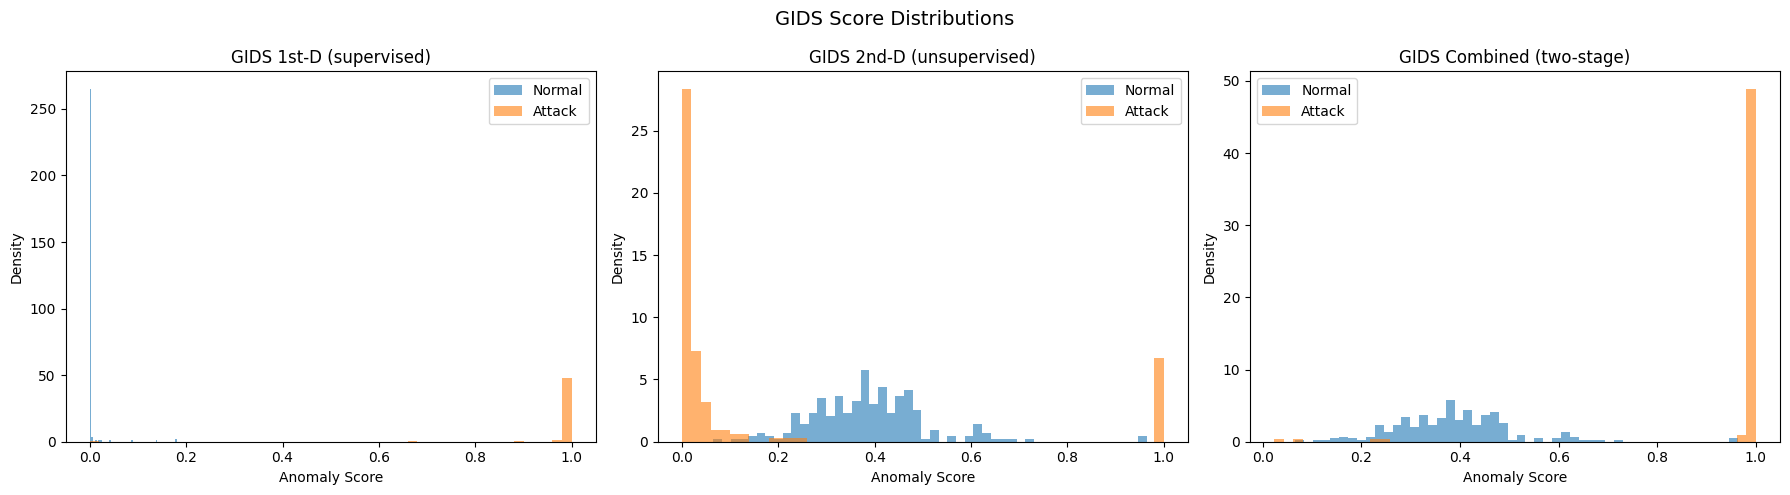

In [25]:
# =============================================
# GIDS Score Distribution Visualization
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, scores) in zip(axes, [("1st-D (supervised)", d1_scores_te),
                                       ("2nd-D (unsupervised)", d2_scores_te),
                                       ("Combined (two-stage)", combined_scores)]):
    normal_s = scores[y_test_all == 0]
    attack_s = scores[y_test_all == 1]
    ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
    ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
    ax.set_title(f"GIDS {name}")
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("GIDS Score Distributions", fontsize=14)
plt.tight_layout()
plt.show()

===== GIDS Combined Confusion Matrix (Window-Level) =====
TN=235  FP=5  FN=4  TP=153
Precision: 0.9684
Recall:    0.9745
F1:        0.9714


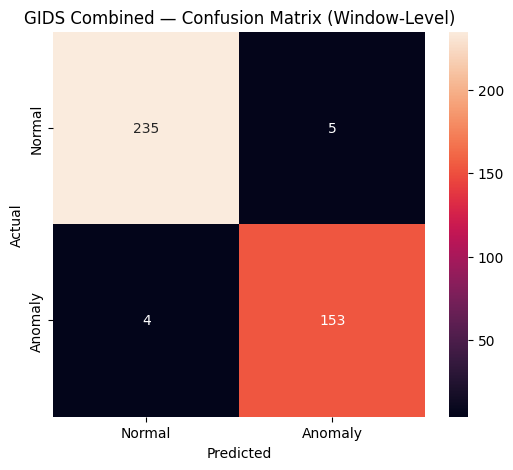

In [26]:
# =============================================
# GIDS Confusion Matrix
# =============================================

# Use the combined two-stage approach (paper's recommended)
thr_gids = np.percentile(combined_tr, THR_PCT)
y_pred_gids = (combined_scores > thr_gids).astype(int)

cm_gids = confusion_matrix(y_test_all, y_pred_gids)
tn, fp, fn, tp = cm_gids.ravel()

print("===== GIDS Combined Confusion Matrix (Window-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(y_test_all, y_pred_gids):.4f}")
print(f"Recall:    {recall_score(y_test_all, y_pred_gids):.4f}")
print(f"F1:        {f1_score(y_test_all, y_pred_gids):.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gids, annot=True, fmt="d", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("GIDS Combined — Confusion Matrix (Window-Level)")
plt.show()

In [27]:
# =============================================
# GIDS Model Size, Latency & Energy
# =============================================

print("GIDS model sizes:")
print("  Generator:", model_size_stats(G_gids))
print("  1st Discriminator:", model_size_stats(D1_gids))
print("  2nd Discriminator:", model_size_stats(D2_gids))
print("  Combined (D1+D2):", combined_model_size(D1_gids, D2_gids))
print("  Full (G+D1+D2):", combined_model_size(G_gids, D1_gids, D2_gids))

# Latency: two-stage inference (D1 -> D2)
def gids_combined_one():
    x = torch.tensor(X_test_s_gids[:1], dtype=torch.float32, device=device)
    with torch.no_grad():
        d1_out = D1_gids(x)
        d2_out = D2_gids(x)

gids_lat = measure_latency_ms(gids_combined_one, runs=500)
print(f"\nGIDS two-stage latency: {gids_lat:.4f} ms/window")

# Energy
E_gids, P_gids, T_gids = nvml_energy_joules(repeat_workload(gids_combined_one, n=500))
print(f"GIDS energy: {E_gids/500:.6f} J/window, avg power: {P_gids:.2f} W")

GIDS model sizes:
  Generator: {'Params': 137484, 'Size (MB)': 0.5244598388671875}
  1st Discriminator: {'Params': 9985, 'Size (MB)': 0.038089752197265625}
  2nd Discriminator: {'Params': 9985, 'Size (MB)': 0.038089752197265625}
  Combined (D1+D2): {'Params': 19970, 'Size (MB)': 0.07617950439453125}
  Full (G+D1+D2): {'Params': 157454, 'Size (MB)': 0.6006393432617188}

GIDS two-stage latency: 0.4467 ms/window
GIDS energy: 0.023568 J/window, avg power: 66.38 W


In [28]:
# =============================================
# GIDS vs GANomaly Comparison (Window-Level)
# =============================================

comparison_rows = [
    {"model": "GANomaly", "eval_level": "window",
     **compute_metrics_99pct(y_test_all, gan_scores, gan_scores_tr)},
    {"model": "GIDS 1st-D (supervised)", "eval_level": "window", **d1_metrics},
    {"model": "GIDS 2nd-D (unsupervised)", "eval_level": "window", **d2_metrics},
    {"model": "GIDS Combined", "eval_level": "window", **combined_metrics},
]

comparison_df = fmt_cols(
    pd.DataFrame(comparison_rows),
    ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]
)
comparison_df[["model", "roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]]

,model,roc_auc,pr_auc,accuracy,precision,recall,f1
0,GANomaly,0.9949,0.9902,0.9572,0.9070,0.9936,0.9483
1,GIDS 1st-D (supervised),0.9939,0.9959,0.9773,0.9568,0.9873,0.9718
2,GIDS 2nd-D (unsupervised),0.1357,0.3617,0.6448,0.8077,0.1338,0.2295
3,GIDS Combined,0.9756,0.9848,0.9773,0.9684,0.9745,0.9714


## 6. Sequence-Based Models (MAD-GAN & TadGAN)

These models operate on **sequences** of consecutive time windows, capturing temporal dependencies across windows that single-window models cannot.

### MAD-GAN
**Reference:** Li, D., Chen, D., Shi, L., Jin, B., Goh, J., & Ng, S.-K. (2019). *MAD-GAN: Multivariate Anomaly Detection for Time Series Data with Generative Adversarial Networks.* ICANN.

**Architecture:** LSTM-RNN based GAN for multivariate time series:
- **Generator $G$:** 3-layer LSTM (depth 3, matching paper Section 5.1) that maps random noise sequences $\mathbf{Z} \in \mathbb{R}^{T \times z_{dim}}$ to synthetic time series $\hat{\mathbf{X}} \in \mathbb{R}^{T \times D}$
- **Discriminator $D$:** 1-layer LSTM that classifies sequences as real or generated

**Anomaly Scoring (DR-Score):** At test time, for each sequence:
1. **Reconstruction residual:** Optimize latent $\mathbf{Z}^*$ to minimize $|\mathbf{X} - G(\mathbf{Z}^*)|$ via gradient descent in latent space (iterative search)
2. **Discrimination score:** $1 - \sigma(D(\mathbf{X}))$ — how "fake" the discriminator thinks the real sequence is
3. **Combined:** $\text{DR-Score} = \lambda \cdot \text{Res} + (1-\lambda) \cdot \text{Dis}$

### TadGAN
**Reference:** Geiger, A., Liu, D., Alnegheimish, S., Cuesta-Infante, A., & Veeramachaneni, K. (2020). *TadGAN: Time Series Anomaly Detection Using Generative Adversarial Networks.* IEEE Big Data.

**Architecture:** WGAN-GP with cycle consistency:
- **Encoder $E$:** 1-layer bidirectional LSTM (matching paper Section VI-B) — maps input sequences to latent space
- **Generator $G$:** 2-layer bidirectional LSTM with dropout — reconstructs sequences from latent codes
- **Critic $C_x$:** Conv1d + LSTM — Wasserstein critic that scores how "real" a sequence looks

**Training:** Uses Wasserstein distance with gradient penalty (WGAN-GP) + cycle consistency loss $\|\mathbf{x} - G(E(\mathbf{x}))\|_1$ to ensure faithful reconstruction.

**Anomaly Score:** Combines normalized reconstruction error $Z_{RE}$ and Critic output $Z_{C_x}$:
$a(\mathbf{x}) = \alpha \cdot Z_{RE}(\mathbf{x}) + (1 - \alpha) \cdot Z_{C_x}(\mathbf{x})$

In [29]:
# === MAD-GAN ===
class MADGAN_G(nn.Module):
    """Generator: 3-layer LSTM (paper Sec 5.1: depth 3, matching paper architecture)."""
    def __init__(self, zdim, hidden, D):
        super().__init__()
        self.rnn = nn.LSTM(zdim, hidden, num_layers=3, batch_first=True)
        self.fc = nn.Linear(hidden, D)
    def forward(self, z):
        h, _ = self.rnn(z)
        return self.fc(h)

class MADGAN_D(nn.Module):
    """Discriminator: 1-layer LSTM (paper Sec 5.1: depth 1)."""
    def __init__(self, D, hidden):
        super().__init__()
        self.rnn = nn.LSTM(D, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.fc(h[:, -1, :])

def train_madgan(Xtr_s, zdim=16, hidden=64, batch=64, epochs=100, lr=2e-4):
    G = MADGAN_G(zdim, hidden, D=Xtr_s.shape[2]).to(device)
    Dm = MADGAN_D(D=Xtr_s.shape[2], hidden=hidden).to(device)
    optG = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
    optD = optim.Adam(Dm.parameters(), lr=lr, betas=(0.5, 0.9))
    bce = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_s, dtype=torch.float32)),
                        batch_size=batch, shuffle=True, drop_last=True)
    for ep in range(epochs):
        for (x,) in loader:
            x = x.to(device)
            B, T, _ = x.shape
            z = torch.randn(B, T, zdim, device=device)
            x_fake = G(z).detach()
            lossD = bce(Dm(x), torch.ones(B,1,device=device)) + bce(Dm(x_fake), torch.zeros(B,1,device=device))
            optD.zero_grad(); lossD.backward(); optD.step()

            z = torch.randn(B, T, zdim, device=device)
            lossG = bce(Dm(G(z)), torch.ones(B,1,device=device))
            optG.zero_grad(); lossG.backward(); optG.step()
        if ep % 20 == 0:
            print(f"[MAD-GAN] epoch {ep}: D={lossD.item():.4f} G={lossG.item():.4f}")
    return G, Dm

def madgan_score_sequences(G, Dm, X, zdim=16, iters=10, lr_z=0.05, lam=0.5):
    dev = next(G.parameters()).device
    X_t = torch.tensor(X, dtype=torch.float32, device=dev)
    Dm.eval()
    scores = []
    N, T, D = X.shape
    for i in range(N):
        x = X_t[i:i+1]
        z = torch.randn(1, T, zdim, device=dev, requires_grad=True)
        optZ = optim.Adam([z], lr=lr_z)
        G.train()
        for _ in range(iters):
            with torch.backends.cudnn.flags(enabled=False):
                xhat = G(z)
                loss = torch.mean(torch.abs(xhat - x))
            optZ.zero_grad(); loss.backward(); optZ.step()
        G.eval()
        with torch.no_grad():
            xhat = G(z)
            residual = torch.mean(torch.abs(xhat - x)).item()
            disc_anom = 1.0 - torch.sigmoid(Dm(x)).item()
            scores.append(lam * residual + (1 - lam) * disc_anom)
    return np.array(scores)

def madgan_score_one_seq(Gm, Dm, X_sample, zdim=16, iters=10, lr_z=0.05, lam=0.5):
    dev = next(Gm.parameters()).device
    x = torch.tensor(X_sample, dtype=torch.float32, device=dev)
    B, T, _ = x.shape
    z = torch.randn(B, T, zdim, device=dev, requires_grad=True)
    optZ = torch.optim.Adam([z], lr=lr_z)
    Gm.train()
    for _ in range(iters):
        with torch.backends.cudnn.flags(enabled=False):
            xhat = Gm(z); loss = torch.mean(torch.abs(xhat - x))
        optZ.zero_grad(set_to_none=True); loss.backward(); optZ.step()
    Gm.eval()
    with torch.no_grad():
        xhat = Gm(z)
        residual = torch.mean(torch.abs(xhat - x))
        disc_anom = 1.0 - torch.sigmoid(Dm(x)).mean()
        return lam * residual + (1 - lam) * disc_anom

In [30]:
# === TadGAN ===
class TadGAN_E(nn.Module):
    """Encoder: 1-layer bidirectional LSTM (paper Sec VI-B)."""
    def __init__(self, D, hidden, zdim):
        super().__init__()
        self.rnn = nn.LSTM(D, hidden, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2, zdim)  # *2 for bidirectional
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.fc(h)

class TadGAN_G(nn.Module):
    """Generator: 2-layer bidirectional LSTM with dropout (paper Sec VI-B)."""
    def __init__(self, zdim, hidden, D):
        super().__init__()
        self.rnn = nn.LSTM(zdim, hidden, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Linear(hidden * 2, D)  # *2 for bidirectional
    def forward(self, z):
        h, _ = self.rnn(z)
        return self.fc(h)

class TadGAN_C(nn.Module):
    """Critic: Conv1d + LSTM (paper Sec VI-B: '1-D convolutional layer for both Critics')."""
    def __init__(self, D, hidden):
        super().__init__()
        self.conv = nn.Conv1d(D, D, kernel_size=3, padding=1)
        self.rnn = nn.LSTM(D, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        # x: (B, T, D) -> conv expects (B, D, T)
        x_conv = torch.relu(self.conv(x.transpose(1, 2))).transpose(1, 2)
        h, _ = self.rnn(x_conv)
        return self.fc(h[:, -1, :])

def gradient_penalty(C, real, fake):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, device=real.device)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    with torch.backends.cudnn.flags(enabled=False):
        out = C(interp)
    grad = torch.autograd.grad(out, interp, grad_outputs=torch.ones_like(out),
                                create_graph=True, retain_graph=True, only_inputs=True)[0]
    return ((grad.reshape(B, -1).norm(2, dim=1) - 1) ** 2).mean()

def train_tadgan(Xtr_s, zdim=16, hidden=64, batch=64, epochs=200, lr=1e-4,
                 n_critic=5, gp_w=10.0, cycle_w=10.0):
    En = TadGAN_E(D=Xtr_s.shape[2], hidden=hidden, zdim=zdim).to(device)
    Gn = TadGAN_G(zdim=zdim, hidden=hidden, D=Xtr_s.shape[2]).to(device)
    Cn = TadGAN_C(D=Xtr_s.shape[2], hidden=hidden).to(device)
    optEG = optim.Adam(list(En.parameters()) + list(Gn.parameters()), lr=lr, betas=(0.5, 0.9))
    optC  = optim.Adam(Cn.parameters(), lr=lr, betas=(0.5, 0.9))
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_s, dtype=torch.float32)),
                        batch_size=batch, shuffle=True, drop_last=True)
    for ep in range(epochs):
        for (x,) in loader:
            x = x.to(device)
            for _ in range(n_critic):
                z = En(x).detach(); x_fake = Gn(z).detach()
                lossC = Cn(x_fake).mean() - Cn(x).mean() + gp_w * gradient_penalty(Cn, x, x_fake)
                optC.zero_grad(); lossC.backward(); optC.step()
            z = En(x); x_hat = Gn(z)
            lossEG = -Cn(x_hat).mean() + cycle_w * torch.mean(torch.abs(x_hat - x))
            optEG.zero_grad(); lossEG.backward(); optEG.step()
        if ep % 50 == 0:
            print(f"[TadGAN] epoch {ep}: C={lossC.item():.4f} EG={lossEG.item():.4f}")
    return En, Gn, Cn

def tadgan_score_sequences(E, G, C, X, alpha=0.5, mode="mul"):
    E.eval(); G.eval(); C.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        z = E(X_t); x_hat = G(z)
        recon = torch.mean(torch.abs(x_hat - X_t), dim=(1,2))
        critic_anom = -C(X_t).squeeze(1)
        score = recon * critic_anom if mode != "add" else alpha * recon + (1 - alpha) * critic_anom
    return score.detach().cpu().numpy()

In [31]:
# Build sequences
feature_cols = get_feature_cols(train_w)
Xtr_all, ytr_seq, atr_seq = make_sequences(train_w, t_seq=T_SEQ, stride=1, feature_cols=feature_cols)
Xte_all, yte_seq, ate_seq = make_sequences(test_w,  t_seq=T_SEQ, stride=1, feature_cols=feature_cols)

Xtr = Xtr_all[ytr_seq == 0]
print("Train normal sequences:", Xtr.shape[0])

Xtr_s, Xte_s, seq_scaler = scale_train_test_sequences(Xtr, Xte_all)

# Train MAD-GAN
Gm, Dm = train_madgan(Xtr_s, zdim=ZDIM, hidden=64, epochs=100)

# Train TadGAN
En, Gn, Cn = train_tadgan(Xtr_s, zdim=ZDIM, hidden=64, epochs=200, lr=5e-5, n_critic=5, gp_w=10.0, cycle_w=1.0)

# Score
mad_scores = madgan_score_sequences(Gm, Dm, Xte_s, zdim=ZDIM, iters=10, lr_z=0.05, lam=0.5)
tad_scores = tadgan_score_sequences(En, Gn, Cn, Xte_s, mode="add", alpha=0.5)

print("MAD-GAN ROC:", roc_auc_score(yte_seq, mad_scores), "PR:", average_precision_score(yte_seq, mad_scores))
print("TadGAN ROC:", roc_auc_score(yte_seq, tad_scores), "PR:", average_precision_score(yte_seq, tad_scores))

Train normal sequences: 67
[MAD-GAN] epoch 0: D=1.3874 G=0.7091
[MAD-GAN] epoch 20: D=1.3803 G=0.7094
[MAD-GAN] epoch 40: D=1.3821 G=0.7041
[MAD-GAN] epoch 60: D=1.3766 G=0.7101
[MAD-GAN] epoch 80: D=1.3671 G=0.7137
[TadGAN] epoch 0: C=9.7983 EG=0.7094
[TadGAN] epoch 50: C=8.0693 EG=0.6553
[TadGAN] epoch 100: C=1.8094 EG=-0.8957
[TadGAN] epoch 150: C=0.4024 EG=-1.3199
MAD-GAN ROC: 0.9931887532693984 PR: 0.9984885676956854
TadGAN ROC: 0.8451939843068876 PR: 0.9664218418185299


In [32]:
def run_madgan_tseq_ablation(train_w, test_w, t_seq_list, stride=1, zdim=16, hidden=64, epochs=100, iters=10):
    feature_cols = get_feature_cols(train_w)
    all_rows, pa_rows = [], []
    for t_seq in t_seq_list:
        Xtr_all, ytr_seq, atr_seq = make_sequences(train_w, t_seq=t_seq, stride=stride, feature_cols=feature_cols)
        Xte_all, yte_seq, ate_seq = make_sequences(test_w,  t_seq=t_seq, stride=stride, feature_cols=feature_cols)
        Xtr = Xtr_all[ytr_seq == 0]
        Xtr_s, Xte_s, _ = scale_train_test_sequences(Xtr, Xte_all)
        G, D = train_madgan(Xtr_s, zdim=zdim, hidden=hidden, epochs=epochs)
        scores = madgan_score_sequences(G, D, Xte_s, zdim=zdim, iters=iters)
        roc = roc_auc_score(yte_seq, scores)
        pr = average_precision_score(yte_seq, scores)
        all_rows.append({"t_seq": t_seq, "roc_auc": roc, "pr_auc": pr, "n_seq": len(yte_seq), "n_anom_seq": int(yte_seq.sum())})
        pa = per_attack_breakdown(scores, yte_seq, ate_seq)
        pa["t_seq"] = t_seq
        pa_rows.append(pa)
        print(f"t_seq={t_seq}: ROC={roc:.4f} PR={pr:.4f}")
    return pd.DataFrame(all_rows), pd.concat(pa_rows, ignore_index=True)

t_seq_list = [10, 20, 40]
summary_df, per_attack_df = run_madgan_tseq_ablation(train_w, test_w, t_seq_list)
summary_df

[MAD-GAN] epoch 0: D=1.3856 G=0.6866
[MAD-GAN] epoch 20: D=1.3627 G=0.7294
[MAD-GAN] epoch 40: D=1.2574 G=0.8614
[MAD-GAN] epoch 60: D=0.8719 G=1.4105
[MAD-GAN] epoch 80: D=0.4854 G=2.4943
t_seq=10: ROC=0.9870 PR=0.9854
[MAD-GAN] epoch 0: D=1.3843 G=0.7057
[MAD-GAN] epoch 20: D=1.3734 G=0.7198
[MAD-GAN] epoch 40: D=1.3522 G=0.7421
[MAD-GAN] epoch 60: D=1.3131 G=0.7881
[MAD-GAN] epoch 80: D=1.0348 G=1.3863
t_seq=20: ROC=0.9831 PR=0.9898
[MAD-GAN] epoch 0: D=1.3905 G=0.6482
[MAD-GAN] epoch 20: D=1.3790 G=0.6691
[MAD-GAN] epoch 40: D=1.3671 G=0.6912
[MAD-GAN] epoch 60: D=1.3442 G=0.7205
[MAD-GAN] epoch 80: D=1.3130 G=0.7662
t_seq=40: ROC=0.9920 PR=0.9983


,t_seq,roc_auc,pr_auc,n_seq,n_anom_seq
0,10,0.986979,0.985383,388,196
1,20,0.983051,0.989843,378,236
2,40,0.991990,0.998266,358,296


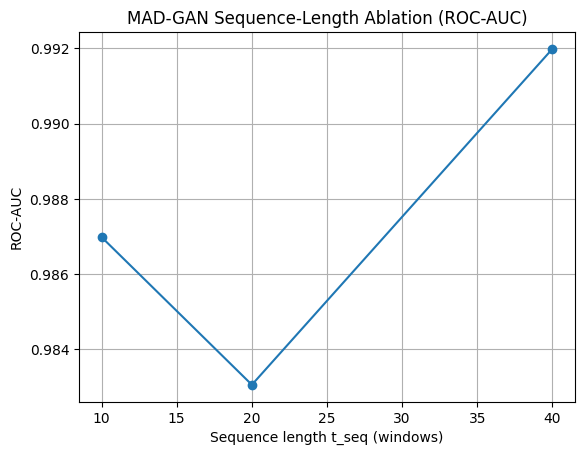

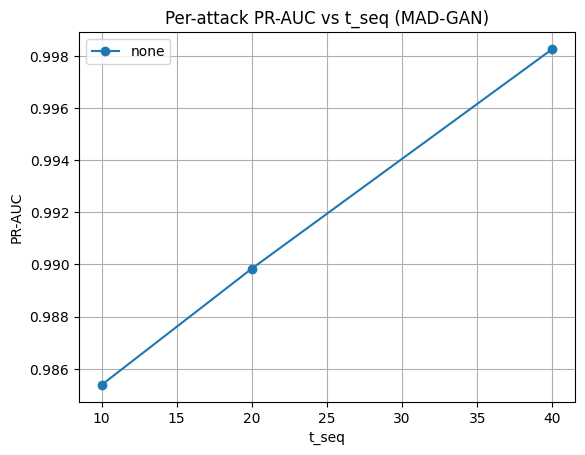

In [33]:
plt.figure()
plt.plot(summary_df["t_seq"], summary_df["roc_auc"], marker="o")
plt.xlabel("Sequence length t_seq (windows)")
plt.ylabel("ROC-AUC")
plt.title("MAD-GAN Sequence-Length Ablation (ROC-AUC)")
plt.grid(True)
plt.show()

plt.figure()
for atk in sorted(per_attack_df["attack"].unique()):
    sub = per_attack_df[per_attack_df["attack"] == atk].sort_values("t_seq")
    plt.plot(sub["t_seq"], sub["pr_auc"], marker="o", label=atk)
plt.xlabel("t_seq"); plt.ylabel("PR-AUC")
plt.title("Per-attack PR-AUC vs t_seq (MAD-GAN)")
plt.grid(True); plt.legend(); plt.show()

In [34]:
def run_madgan_multiseed(train_w, test_w, t_seq=40, seeds=(0,1,2), zdim=16, hidden=64,
                         train_epochs=100, score_iters=10):
    feature_cols = get_feature_cols(train_w)
    results, pa_all = [], []
    for seed in seeds:
        print(f"\n===== SEED {seed} =====")
        set_seed(seed)
        Xtr_all, ytr_seq, atr_seq = make_sequences(train_w, t_seq=t_seq, feature_cols=feature_cols)
        Xte_all, yte_seq, ate_seq = make_sequences(test_w,  t_seq=t_seq, feature_cols=feature_cols)
        Xtr = Xtr_all[ytr_seq == 0]
        Xtr_s, Xte_s, _ = scale_train_test_sequences(Xtr, Xte_all)
        G, D = train_madgan(Xtr_s, zdim=zdim, hidden=hidden, epochs=train_epochs)
        scores = madgan_score_sequences(G, D, Xte_s, zdim=zdim, iters=score_iters)
        roc = roc_auc_score(yte_seq, scores)
        pr = average_precision_score(yte_seq, scores)
        results.append({"seed": seed, "roc_auc": roc, "pr_auc": pr})
        pa = per_attack_breakdown(scores, yte_seq, ate_seq)
        pa["seed"] = seed
        pa_all.append(pa)
    return pd.DataFrame(results), pd.concat(pa_all, ignore_index=True)

results_df, per_attack_ms_df = run_madgan_multiseed(train_w, test_w, t_seq=40, seeds=(0,1,2), score_iters=10)
print(f"ROC-AUC: {results_df['roc_auc'].mean():.4f} \u00b1 {results_df['roc_auc'].std():.4f}")
print(f"PR-AUC : {results_df['pr_auc'].mean():.4f} \u00b1 {results_df['pr_auc'].std():.4f}")


===== SEED 0 =====
[MAD-GAN] epoch 0: D=1.3950 G=0.7344
[MAD-GAN] epoch 20: D=1.3838 G=0.7355
[MAD-GAN] epoch 40: D=1.3748 G=0.7377
[MAD-GAN] epoch 60: D=1.3671 G=0.7403
[MAD-GAN] epoch 80: D=1.3418 G=0.7544

===== SEED 1 =====
[MAD-GAN] epoch 0: D=1.3943 G=0.7558
[MAD-GAN] epoch 20: D=1.3887 G=0.7441
[MAD-GAN] epoch 40: D=1.3827 G=0.7419
[MAD-GAN] epoch 60: D=1.3673 G=0.7525
[MAD-GAN] epoch 80: D=1.3583 G=0.7532

===== SEED 2 =====
[MAD-GAN] epoch 0: D=1.3807 G=0.6713
[MAD-GAN] epoch 20: D=1.3727 G=0.6852
[MAD-GAN] epoch 40: D=1.3784 G=0.6884
[MAD-GAN] epoch 60: D=1.3749 G=0.6969
[MAD-GAN] epoch 80: D=1.3393 G=0.7263
ROC-AUC: 0.9925 ± 0.0003
PR-AUC : 0.9984 ± 0.0001


## 7. MAD-GAN Latency-Performance Tradeoff

In [35]:
def madgan_latency_ms_fn(Gm, Dm, X_sample, zdim=16, iters=10, lr_z=0.05, lam=0.5):
    dev = next(Gm.parameters()).device
    X_t = torch.tensor(X_sample, dtype=torch.float32, device=dev)
    def _fn():
        x = X_t; B, T, _ = x.shape
        z = torch.randn(B, T, zdim, device=dev, requires_grad=True)
        optZ = torch.optim.Adam([z], lr=lr_z)
        Gm.train()
        for _ in range(iters):
            with torch.backends.cudnn.flags(enabled=False):
                xhat = Gm(z); loss = torch.mean(torch.abs(xhat - x))
            optZ.zero_grad(); loss.backward(); optZ.step()
        Gm.eval()
        with torch.no_grad():
            xhat = Gm(z)
            _ = lam * torch.mean(torch.abs(xhat - x)) + (1-lam) * (1.0 - torch.sigmoid(Dm(x)).mean())
    times = []
    for _ in range(2): _fn()  # warmup
    for _ in range(3):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0 = time.perf_counter(); _fn()
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times) * 1000)

iters_list = [10, 20, 40, 60, 100]
trade_rows = []
X_sample = Xte_s[:1]
for itr in iters_list:
    ms = madgan_latency_ms_fn(Gm, Dm, X_sample, zdim=ZDIM, iters=itr)
    scores = madgan_score_sequences(Gm, Dm, Xte_s, zdim=ZDIM, iters=itr)
    roc = roc_auc_score(yte_seq, scores)
    pr = average_precision_score(yte_seq, scores)
    # pr_r = replay_pr_auc(scores, yte_seq, ate_seq)
    trade_rows.append({"score_iters": itr, "latency_ms_per_seq": ms, "roc_auc": roc, "pr_auc": pr})
    print(f"iters={itr:3d} | {ms:8.1f} ms | ROC={roc:.4f} | PR={pr:.4f}")

trade_df = pd.DataFrame(trade_rows)
trade_df

iters= 10 |    249.4 ms | ROC=0.9931 | PR=0.9985
iters= 20 |    508.1 ms | ROC=0.9931 | PR=0.9985
iters= 40 |   1050.1 ms | ROC=0.9932 | PR=0.9985
iters= 60 |   1496.9 ms | ROC=0.9932 | PR=0.9985
iters=100 |   2501.1 ms | ROC=0.9932 | PR=0.9985


,score_iters,latency_ms_per_seq,roc_auc,pr_auc
0,10,249.443192,0.993134,0.998474
1,20,508.073590,0.993134,0.998474
2,40,1050.056534,0.993189,0.998486
3,60,1496.928626,0.993189,0.998486
4,100,2501.075431,0.993189,0.998486


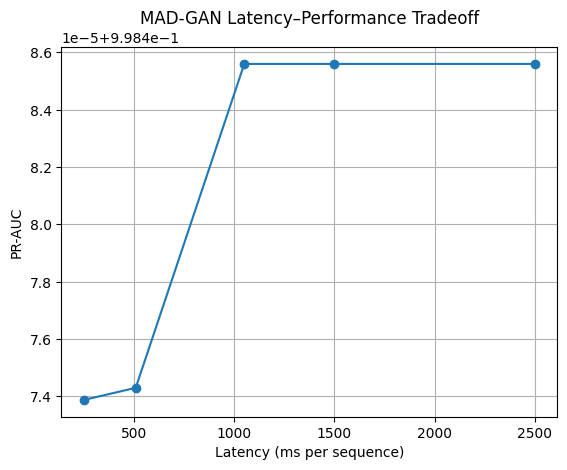

In [36]:
plt.figure()
plt.plot(trade_df["latency_ms_per_seq"], trade_df["pr_auc"], marker="o")
plt.xlabel("Latency (ms per sequence)"); plt.ylabel("PR-AUC")
plt.title("MAD-GAN Latency\u2013Performance Tradeoff")
plt.grid(True); plt.show()

## 8. Packet/Window Statistics & Detection Latency

In [37]:
window_sec = 1.0

for label, pkts in [("Train", train_pkts), ("Test", test_pkts)]:
    tmp = pkts.copy()
    t0 = tmp["frame.time_epoch"].min()
    tmp["w"] = np.floor((tmp["frame.time_epoch"] - t0) / window_sec).astype("int64")
    pkt_per_w = tmp.groupby("w").size()
    print(f"\n{label} packets per window:")
    print(pkt_per_w.describe())
    counts = pkt_per_w.sort_index().values
    seq_pkt_counts = np.convolve(counts, np.ones(T_SEQ, dtype=int), mode="valid")
    print(f"\n{label} packets per sequence (t_seq={T_SEQ}):")
    print(pd.Series(seq_pkt_counts).describe())


Train packets per window:
count     553.000000
mean     2176.739602
std       480.991771
min       371.000000
25%      1761.000000
50%      1956.000000
75%      2608.000000
max      3422.000000
dtype: float64

Train packets per sequence (t_seq=40):
count       514.000000
mean      87401.943580
std       13745.512842
min       67279.000000
25%       75899.750000
50%       86454.500000
75%       95561.750000
max      122935.000000
dtype: float64

Test packets per window:
count     397.000000
mean     1993.982368
std       444.230332
min       439.000000
25%      1695.000000
50%      1755.000000
75%      2329.000000
max      3299.000000
dtype: float64

Test packets per sequence (t_seq=40):
count       358.000000
mean      79828.854749
std        9338.102824
min       65164.000000
25%       72292.500000
50%       78856.500000
75%       84983.000000
max      104139.000000
dtype: float64


## 9. Confusion Matrices (Sequence / Window / Packet Level)

===== Sequence-Level Confusion Matrix =====
[[ 50  12]
 [  3 293]]
Precision: 0.9607
Recall:    0.9899
F1:        0.9750


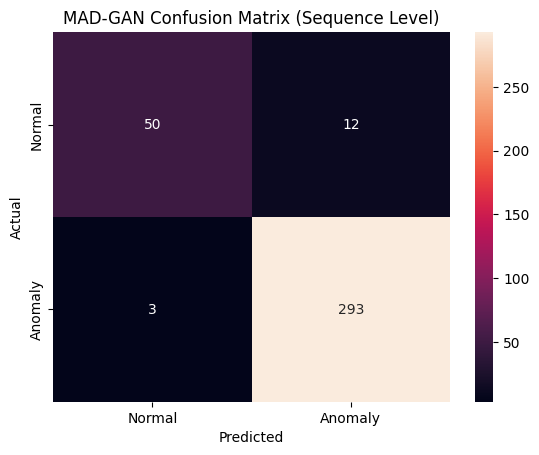


===== Window-Level Confusion Matrix =====
Precision: 0.4131
Recall:    0.8025
F1:        0.5455


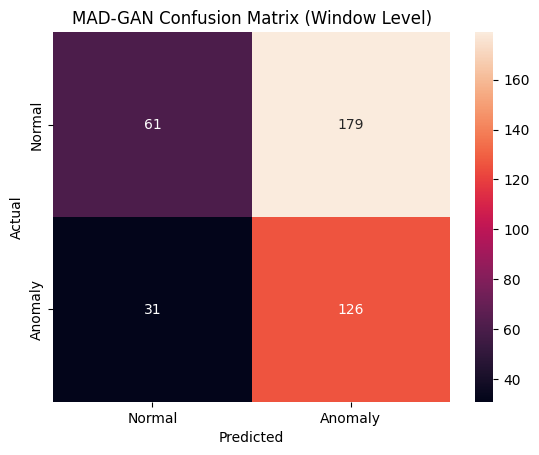


===== Packet-Level Confusion Matrix =====
Total packets: 791,611
TN=157,022 FP=503,755 FN=26,013 TP=104,821
Precision: 0.1722
Recall:    0.8012
F1:        0.2835


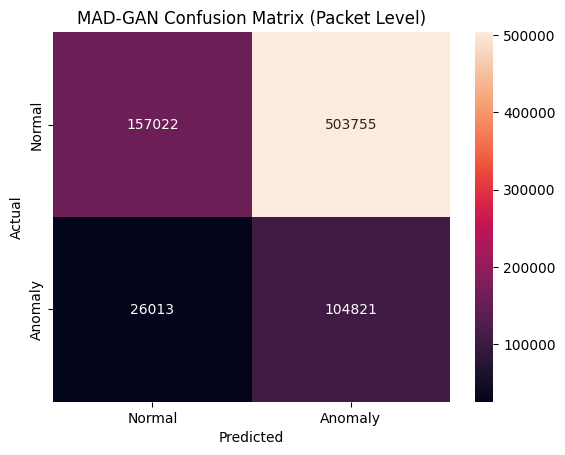

In [38]:
# Threshold from train-normal
train_scores_cm = madgan_score_sequences(Gm, Dm, Xtr_s, zdim=ZDIM, iters=10, lr_z=0.05, lam=0.5)
thr_cm = np.percentile(train_scores_cm, THR_PCT)

test_scores_cm = madgan_score_sequences(Gm, Dm, Xte_s, zdim=ZDIM, iters=10, lr_z=0.05, lam=0.5)

# --- Sequence-level ---
y_true_seq = yte_seq.astype(int)
y_pred_seq = (test_scores_cm > thr_cm).astype(int)
cm_seq = confusion_matrix(y_true_seq, y_pred_seq)
print("===== Sequence-Level Confusion Matrix =====")
print(cm_seq)
print(f"Precision: {precision_score(y_true_seq, y_pred_seq):.4f}")
print(f"Recall:    {recall_score(y_true_seq, y_pred_seq):.4f}")
print(f"F1:        {f1_score(y_true_seq, y_pred_seq):.4f}")

plt.figure()
sns.heatmap(cm_seq, annot=True, fmt="d", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("MAD-GAN Confusion Matrix (Sequence Level)"); plt.show()

# --- Window-level ---
window_true = test_w["y_window"].astype(int).values
window_pred = np.zeros_like(window_true)
window_pred[:len(y_pred_seq)] = y_pred_seq
cm_win = confusion_matrix(window_true, window_pred)
print("\n===== Window-Level Confusion Matrix =====")
print(f"Precision: {precision_score(window_true, window_pred):.4f}")
print(f"Recall:    {recall_score(window_true, window_pred):.4f}")
print(f"F1:        {f1_score(window_true, window_pred):.4f}")

plt.figure()
sns.heatmap(cm_win, annot=True, fmt="d", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("MAD-GAN Confusion Matrix (Window Level)"); plt.show()

# --- Packet-level ---
test_tmp = test_pkts.copy()
t0_p = test_tmp["frame.time_epoch"].min()
test_tmp["w"] = np.floor((test_tmp["frame.time_epoch"] - t0_p) / 1.0).astype(int)
unique_windows = sorted(test_tmp["w"].unique())
window_to_pred = {w: y_pred_seq[i] if i < len(y_pred_seq) else 0 for i, w in enumerate(unique_windows)}
test_tmp["y_pred"] = test_tmp["w"].map(window_to_pred)
cm_pkt = confusion_matrix(test_tmp["y"].astype(int).values, test_tmp["y_pred"].astype(int).values)
tn, fp, fn, tp = cm_pkt.ravel()
print(f"\n===== Packet-Level Confusion Matrix =====")
print(f"Total packets: {len(test_tmp):,}")
print(f"TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {precision_score(test_tmp['y'].astype(int), test_tmp['y_pred'].astype(int)):.4f}")
print(f"Recall:    {recall_score(test_tmp['y'].astype(int), test_tmp['y_pred'].astype(int)):.4f}")
print(f"F1:        {f1_score(test_tmp['y'].astype(int), test_tmp['y_pred'].astype(int)):.4f}")

plt.figure()
sns.heatmap(cm_pkt, annot=True, fmt="d", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("MAD-GAN Confusion Matrix (Packet Level)"); plt.show()

In [39]:
# Per-attack one-vs-normal confusion matrices
atk_all = pd.Series(ate_seq.astype(str)).str.strip().values
attacks = sorted([a for a in np.unique(atk_all) if a != "normal"])
pa_conf_rows = []

for atk in attacks:
    mask = (atk_all == "normal") | (atk_all == atk)
    y_true = (atk_all[mask] == atk).astype(int)
    y_pred = y_pred_seq[mask].astype(int)
    scores = test_scores_cm[mask]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    roc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan
    pr = average_precision_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan
    pa_conf_rows.append({
        "attack": atk, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc, "pr_auc": pr
    })

fmt_cols(pd.DataFrame(pa_conf_rows).sort_values("pr_auc", ascending=False),
         ["precision","recall","f1","roc_auc","pr_auc"])

,attack,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
0,none,50,12,3,293,0.9607,0.9899,0.975,0.9931,0.9985


===== TadGAN: Sequence-Level Confusion Matrix =====
[[ 49  13]
 [ 72 224]]
Precision: 0.9451
Recall:    0.7568
F1:        0.8405


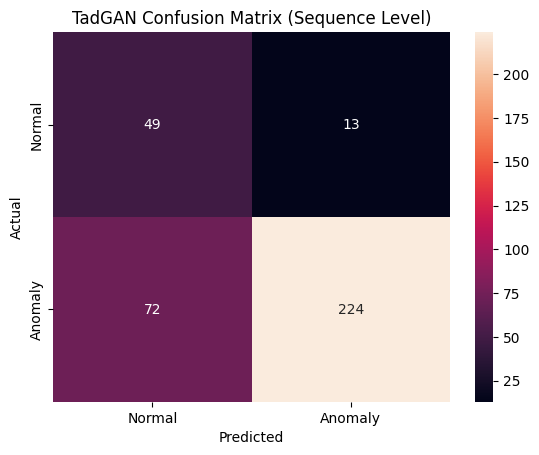

===== TadGAN: Window-Level Confusion Matrix =====
Precision: 0.4051
Recall:    0.6115
F1:        0.4873


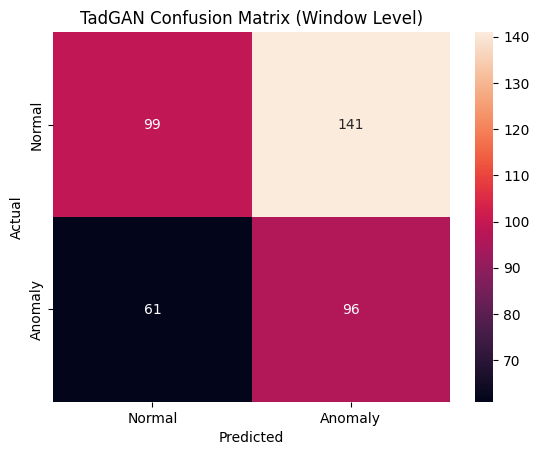

===== TadGAN: Packet-Level Confusion Matrix =====
Total packets: 791,611
TN=268,661 FP=392,116 FN=51,441 TP=79,393
Precision: 0.1684
Recall:    0.6068
F1:        0.2636


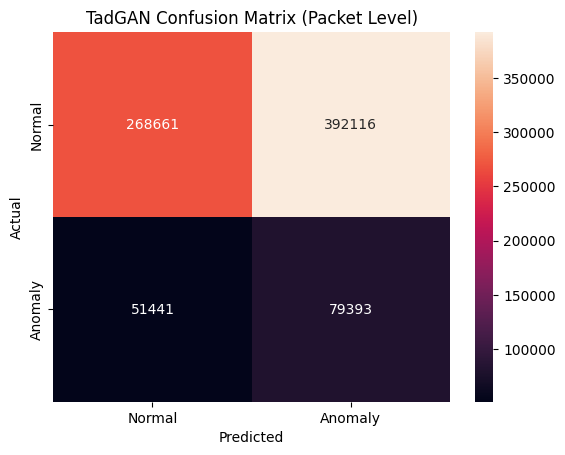

In [40]:
# =============================================
# TadGAN Confusion Matrices (Sequence / Window / Packet Level)
# =============================================

# Score train-normal for threshold
tad_scores_tr_cm = tadgan_score_sequences(En, Gn, Cn, Xtr_s, mode="add", alpha=0.5)
tad_thr_cm = np.percentile(tad_scores_tr_cm, THR_PCT)

tad_scores_te_cm = tad_scores  # already computed in cell above

# --- Sequence-level ---
y_true_seq_tad = yte_seq.astype(int)
y_pred_seq_tad = (tad_scores_te_cm > tad_thr_cm).astype(int)
cm_seq_tad = confusion_matrix(y_true_seq_tad, y_pred_seq_tad)
print("===== TadGAN: Sequence-Level Confusion Matrix =====")
print(cm_seq_tad)
print(f"Precision: {precision_score(y_true_seq_tad, y_pred_seq_tad):.4f}")
print(f"Recall:    {recall_score(y_true_seq_tad, y_pred_seq_tad):.4f}")
print(f"F1:        {f1_score(y_true_seq_tad, y_pred_seq_tad):.4f}")

plt.figure()
sns.heatmap(cm_seq_tad, annot=True, fmt="d", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("TadGAN Confusion Matrix (Sequence Level)"); plt.show()

# --- Window-level ---
window_true_tad = test_w["y_window"].astype(int).values
window_pred_tad = np.zeros_like(window_true_tad)
window_pred_tad[:len(y_pred_seq_tad)] = y_pred_seq_tad
cm_win_tad = confusion_matrix(window_true_tad, window_pred_tad)
tn, fp, fn, tp = cm_win_tad.ravel()
print("===== TadGAN: Window-Level Confusion Matrix =====")
print(f"Precision: {precision_score(window_true_tad, window_pred_tad):.4f}")
print(f"Recall:    {recall_score(window_true_tad, window_pred_tad):.4f}")
print(f"F1:        {f1_score(window_true_tad, window_pred_tad):.4f}")

plt.figure()
sns.heatmap(cm_win_tad, annot=True, fmt="d", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("TadGAN Confusion Matrix (Window Level)"); plt.show()

# --- Packet-level ---
test_tmp_tad = test_pkts.copy()
t0_tad = test_tmp_tad["frame.time_epoch"].min()
test_tmp_tad["w"] = np.floor((test_tmp_tad["frame.time_epoch"] - t0_tad) / 1.0).astype(int)
unique_windows_tad = sorted(test_tmp_tad["w"].unique())
window_to_pred_tad = {w: y_pred_seq_tad[i] if i < len(y_pred_seq_tad) else 0 for i, w in enumerate(unique_windows_tad)}
test_tmp_tad["y_pred"] = test_tmp_tad["w"].map(window_to_pred_tad)
cm_pkt_tad = confusion_matrix(test_tmp_tad["y"].astype(int).values, test_tmp_tad["y_pred"].astype(int).values)
tn, fp, fn, tp = cm_pkt_tad.ravel()
print(f"===== TadGAN: Packet-Level Confusion Matrix =====")
print(f"Total packets: {len(test_tmp_tad):,}")
print(f"TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {precision_score(test_tmp_tad['y'].astype(int), test_tmp_tad['y_pred'].astype(int)):.4f}")
print(f"Recall:    {recall_score(test_tmp_tad['y'].astype(int), test_tmp_tad['y_pred'].astype(int)):.4f}")
print(f"F1:        {f1_score(test_tmp_tad['y'].astype(int), test_tmp_tad['y_pred'].astype(int)):.4f}")

plt.figure()
sns.heatmap(cm_pkt_tad, annot=True, fmt="d", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("TadGAN Confusion Matrix (Packet Level)"); plt.show()

In [41]:
# =============================================
# TadGAN Per-Attack One-vs-Normal Breakdown
# =============================================

atk_all_tad = pd.Series(ate_seq.astype(str)).str.strip().values
attacks_tad = sorted([a for a in np.unique(atk_all_tad) if a != "normal"])
pa_conf_rows_tad = []

for atk in attacks_tad:
    mask = (atk_all_tad == "normal") | (atk_all_tad == atk)
    y_true = (atk_all_tad[mask] == atk).astype(int)
    y_pred = y_pred_seq_tad[mask].astype(int)
    scores = tad_scores_te_cm[mask]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    roc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan
    pr = average_precision_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan
    pa_conf_rows_tad.append({
        "attack": atk, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc, "pr_auc": pr
    })

fmt_cols(pd.DataFrame(pa_conf_rows_tad).sort_values("pr_auc", ascending=False),
         ["precision","recall","f1","roc_auc","pr_auc"])

,attack,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
0,none,49,13,72,224,0.9451,0.7568,0.8405,0.8452,0.9664


### Evaluation Granularity Analysis: Why Performance Degrades Across Levels

The confusion matrices above reveal a consistent pattern: **model performance degrades as we move from sequence-level to window-level to packet-level evaluation.** This is not a flaw in the models but a consequence of the evaluation methodology and the fundamental mismatch between the granularity at which these models operate and the granularity at which we evaluate them.

#### Why MAD-GAN and TadGAN show significant performance change at window-level vs. sequence-level

MAD-GAN and TadGAN are trained and scored at the **sequence level** — each score corresponds to a sliding window of $t_{seq}$ consecutive time windows (e.g., 40 windows = 40 seconds). When evaluated at sequence-level:
- A sequence is labeled anomalous if **any** of its constituent windows is anomalous. This means the model benefits from a "one bad apple" effect — even a single attack window in a 40-window sequence triggers the anomaly label, making detection easier.
- The model sees the full temporal context, which is exactly what it was designed for.

When we **map sequence scores back to window level**, we lose information:
- Each window participates in multiple overlapping sequences. We aggregate (mean or max) the scores from all sequences containing that window.
- **Smoothing effect:** Isolated anomalous windows get their scores diluted by surrounding normal windows. Mean aggregation worsens this.
- **Boundary effects:** Windows near the start/end of the time series participate in fewer sequences.
- **Temporal blurring:** The model's "detection" of an attack sequence gets spread across all windows in that sequence, including normal ones adjacent to the actual attack, increasing false positives while simultaneously reducing the sharpness of true positive detections.

#### Why all GAN-based frameworks perform worse at packet-level

The packet-level evaluation assigns **every packet** within a time window the same prediction as the window itself. This creates a fundamental granularity mismatch:
- A 1-second window may contain **hundreds to thousands of packets** (the dataset has ~2000 CAN messages/second equivalent in Ethernet traffic).
- If only a few packets in a window are actually attack packets, but the window is labeled normal (because the majority of packets are normal), individual attack packets get missed.
- Conversely, if a window is predicted anomalous, **all** packets in that window are marked anomalous — even the legitimate ones, inflating false positives.
- The **class imbalance** at packet level is often different from window level: a window labeled "attack" might contain 90% normal packets and 10% injected attack packets.

#### Is it fair to evaluate these approaches at finer granularity?

**Sequence-level evaluation** is the most natural and fair for MAD-GAN and TadGAN, since that is the granularity at which they produce scores. Similarly, **window-level** is fairest for GANomaly and GIDS.

**Window-level evaluation of sequence models** is reasonable but should be interpreted carefully — it answers a different question: "Can this model localize *which* time windows are anomalous?" rather than "Can this model detect *that* an anomaly occurred?"

**Packet-level evaluation** is the **least fair** for all these approaches, because:
1. None of the models were designed to classify individual packets — they operate on statistical aggregates.
2. The mapping from window/sequence predictions to packets is inherently lossy.
3. Packet-level metrics are dominated by the within-window distribution of normal vs. attack packets, which is outside the model's control.

**Recommendation:** Report sequence-level metrics as primary for MAD-GAN/TadGAN, window-level as primary for GANomaly/GIDS/INDRA, and treat packet-level results as supplementary context. For a true packet-level IDS, one would need models that operate directly on individual packet features, not time-window aggregates.

## 10. Model Size, Latency & Energy

In [42]:
# Model sizes
print("MAD-GAN:", combined_model_size(Gm, Dm))
print("TadGAN:", combined_model_size(En, Gn, Cn))
print("GANomaly:", combined_model_size(Enc_gan, Dec_gan, C_gan))
print("GIDS:", combined_model_size(G_gids, D1_gids, D2_gids))

# Peak CUDA memory
X_sample = Xte_s[:1]
peak_mib = measure_peak_cuda_mem_mb(lambda: madgan_score_one_seq(Gm, Dm, X_sample, zdim=ZDIM, iters=10))
print(f"MAD-GAN peak CUDA mem (iters=10): {peak_mib:.2f} MiB")

MAD-GAN: {'Params': 108365, 'Size (MB)': 0.4133796691894531}
TadGAN: {'Params': 205337, 'Size (MB)': 0.7832984924316406}
GANomaly: {'Params': 1553, 'Size (MB)': 0.005924224853515625}
GIDS: {'Params': 157454, 'Size (MB)': 0.6006393432617188}
MAD-GAN peak CUDA mem (iters=10): 30.65 MiB


## 11. Unified Evaluation (Sequence & Window Level)

In [43]:
# Sequence-level metrics
mad_scores_tr = madgan_score_sequences(Gm, Dm, Xtr_s, zdim=ZDIM, iters=10, lr_z=0.05, lam=0.5)
mad_thr = np.percentile(mad_scores_tr, THR_PCT)
mad_scores_te = madgan_score_sequences(Gm, Dm, Xte_s, zdim=ZDIM, iters=10, lr_z=0.05, lam=0.5)

tad_scores_tr = tadgan_score_sequences(En, Gn, Cn, Xtr_s, mode="add", alpha=0.5)
tad_thr = np.percentile(tad_scores_tr, THR_PCT)
tad_scores_te = tadgan_score_sequences(En, Gn, Cn, Xte_s, mode="add", alpha=0.5)

# Window-level: map sequence scores to windows
n_train_w, n_test_w = len(train_w), len(test_w)
y_train_win = train_w["y_window"].astype(int).to_numpy()
y_test_win = test_w["y_window"].astype(int).to_numpy()
train_normal_mask = (y_train_win == 0)

# GANomaly window scores
X_train_win_s, X_test_win_s, _, gan_sc, _ = fit_scaler_on_normal(train_w, test_w)
gan_scores_tr_win = ganomaly_scores_windows(Enc_gan, Dec_gan, X_train_win_s)
gan_scores_te_win = ganomaly_scores_windows(Enc_gan, Dec_gan, X_test_win_s)

# GIDS window scores (direct, like GANomaly)
gids_combined_tr, _, _ = gids_two_stage_score(D1_gids, D2_gids, X_train_normal_s, detection_threshold=0.1)
gids_combined_te, _, _ = gids_two_stage_score(D1_gids, D2_gids, X_test_s_gids, detection_threshold=0.1)

# Aggregation ablation (mean vs max)
agg_rows = []
for agg in ["mean", "max"]:
    mad_tr_win = seq_scores_to_window_scores(mad_scores_tr, n_train_w, t_seq=T_SEQ, agg=agg)
    mad_te_win = seq_scores_to_window_scores(mad_scores_te, n_test_w, t_seq=T_SEQ, agg=agg)
    agg_rows.append({"model": "MAD-GAN", "agg": agg, **compute_metrics_99pct(y_test_win, mad_te_win, mad_tr_win[train_normal_mask])})

    tad_tr_win = seq_scores_to_window_scores(tad_scores_tr, n_train_w, t_seq=T_SEQ, agg=agg)
    tad_te_win = seq_scores_to_window_scores(tad_scores_te, n_test_w, t_seq=T_SEQ, agg=agg)
    agg_rows.append({"model": "TadGAN", "agg": agg, **compute_metrics_99pct(y_test_win, tad_te_win, tad_tr_win[train_normal_mask])})

    agg_rows.append({"model": "GANomaly", "agg": "direct", **compute_metrics_99pct(y_test_win, gan_scores_te_win, gan_scores_tr_win)})
    agg_rows.append({"model": "GIDS (combined)", "agg": "direct", **compute_metrics_99pct(y_test_win, gids_combined_te, gids_combined_tr)})

abl_df = fmt_cols(pd.DataFrame(agg_rows), ["roc_auc","pr_auc","accuracy","precision","recall","f1"])
abl_df[["model","agg","roc_auc","pr_auc","precision","recall","f1"]].sort_values(["model","agg"])

,model,agg,roc_auc,pr_auc,precision,recall,f1
2,GANomaly,direct,0.9949,0.9902,0.9070,0.9936,0.9483
6,GANomaly,direct,0.9949,0.9902,0.9070,0.9936,0.9483
3,GIDS (combined),direct,0.9756,0.9848,0.9684,0.9745,0.9714
7,GIDS (combined),direct,0.9756,0.9848,0.9684,0.9745,0.9714
4,MAD-GAN,max,0.5847,0.4671,0.4099,1.0000,0.5815
0,MAD-GAN,mean,0.6424,0.5251,0.4121,1.0000,0.5836
5,TadGAN,max,0.4870,0.4270,0.4606,0.7070,0.5578
1,TadGAN,mean,0.5746,0.4956,0.3567,0.3567,0.3567


## 12. INDRA (GRU Autoencoder)

**Reference:** Kukkala, V. K., Thiruloga, S. V., & Pasricha, S. (2020). *INDRA: Intrusion Detection using Recurrent Autoencoders in Automotive Embedded Systems.* IEEE TCAD.

**Architecture:** GRU-based recurrent autoencoder:
- **Input Linear Projection:** $\mathbf{h} = \tanh(W_{in} \mathbf{x} + b_{in})$ — projects each time step's features to higher dimension
- **GRU Encoder:** Processes the projected sequence, learning temporal patterns in normal traffic
- **GRU Decoder:** Reconstructs the sequence from encoder outputs
- **Output Linear Projection:** Maps decoder outputs back to original feature dimension with Tanh activation

**Intrusion Score:** For each message/window in a sequence:
$IS_{signal}(i) = |x_i - \hat{x}_i|^2$ (per-feature reconstruction error)
$IS_{message} = \max_{features} IS_{signal}$ (maximum error across features — catches attacks that affect even a single signal)

The **intrusion threshold** is set at the 99.9th percentile of validation reconstruction loss (paper Section VI-B). The max-over-features strategy is critical: INDRA monitors at signal-level granularity, so even a single compromised signal triggers detection.

**Key Properties:**
- Lightweight: 443 KB memory footprint, 80 $\mu$s inference time on ARM Cortex-A57
- Trained unsupervised on normal data with MSE loss
- Uses MinMaxScaler to [-1, 1] range (matching Tanh activation outputs)
- Subsequence length: 20 messages (paper Section VI-A)

In [44]:
class INDRA_GRU_AE(nn.Module):
    def __init__(self, num_features, subseq_len, linear_out_dim=128, gru_units=64, dropout=0.2):
        super().__init__()
        self.in_proj = nn.Sequential(nn.Linear(num_features, linear_out_dim), nn.Tanh())
        self.drop = nn.Dropout(dropout) if dropout and dropout > 0 else nn.Identity()
        self.gru_enc = nn.GRU(input_size=linear_out_dim, hidden_size=gru_units, num_layers=1, batch_first=True)
        self.gru_dec = nn.GRU(input_size=gru_units, hidden_size=gru_units, num_layers=1, batch_first=True)
        self.out_proj = nn.Sequential(nn.Linear(gru_units, num_features), nn.Tanh())

    def forward(self, x):
        z = self.drop(self.in_proj(x))
        enc_out, _ = self.gru_enc(z)
        enc_out = self.drop(enc_out)
        dec_out, _ = self.gru_dec(enc_out)
        return self.out_proj(self.drop(dec_out))


def train_indra(Xtr_seq_norm, *, linear_out_dim=128, gru_units=64, dropout=0.2,
                lr=1e-3, batch_size=256, epochs=100, seed=0):
    set_seed(seed)
    Xtr = torch.tensor(Xtr_seq_norm, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xtr), batch_size=batch_size, shuffle=True)
    T, D = Xtr.shape[1], Xtr.shape[2]
    model = INDRA_GRU_AE(D, T, linear_out_dim=linear_out_dim, gru_units=gru_units, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for ep in range(epochs):
        losses = []
        for (x,) in loader:
            x = x.to(device)
            loss = loss_fn(model(x), x)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        if ep % 10 == 0 or ep == epochs - 1:
            print(f"[INDRA] epoch {ep}: loss={np.mean(losses):.6f}")
    return model


def indra_scores(model, X_seq, reduce_f="max", reduce_t="mean", batch_size=512):
    model.eval()
    X = torch.tensor(X_seq, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    scores = []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            sq = (model(x) - x) ** 2
            terr = sq.max(dim=2).values if reduce_f == "max" else sq.mean(dim=2)
            s = terr.mean(dim=1) if reduce_t == "mean" else terr.max(dim=1).values
            scores.append(s.cpu().numpy())
    return np.concatenate(scores)

In [45]:
# Build INDRA input (t_seq=20, MinMaxScaler)
t_seq_indra = 20
feat_cols_indra = get_feature_cols(train_w)

X_train_win_i = train_w[feat_cols_indra].astype(float).fillna(0.0).to_numpy()
y_train_win_i = train_w["y_window"].astype(int).to_numpy()
X_test_win_i = test_w[feat_cols_indra].astype(float).fillna(0.0).to_numpy()
y_test_win_i = test_w["y_window"].astype(int).to_numpy()

scaler_indra = MinMaxScaler(feature_range=(-1, 1))
scaler_indra.fit(X_train_win_i[y_train_win_i == 0])
X_train_win_is = scaler_indra.transform(X_train_win_i).astype(np.float32)
X_test_win_is = scaler_indra.transform(X_test_win_i).astype(np.float32)

def make_seq_simple(X, y, t_seq=20, stride=1):
    starts = np.arange(0, len(y) - t_seq + 1, stride)
    X_seq = np.stack([X[s:s+t_seq] for s in starts])
    y_seq = np.array([y[s:s+t_seq].max() for s in starts], dtype=int)
    return X_seq, y_seq

Xtr_seq_all_i, ytr_seq_all_i = make_seq_simple(X_train_win_is, y_train_win_i, t_seq=t_seq_indra)
Xte_seq_i, yte_seq_i = make_seq_simple(X_test_win_is, y_test_win_i, t_seq=t_seq_indra)

Xtr_seq_norm_i = Xtr_seq_all_i[ytr_seq_all_i == 0]
print(f"INDRA: train normal={Xtr_seq_norm_i.shape}, test={Xte_seq_i.shape}, test anomalies={yte_seq_i.sum()}")

# Train
indra_pt = train_indra(Xtr_seq_norm_i, epochs=100, seed=0)

# Evaluate
scores_tr_i = indra_scores(indra_pt, Xtr_seq_norm_i)
scores_te_i = indra_scores(indra_pt, Xte_seq_i)
indra_metrics = compute_metrics_99pct(yte_seq_i, scores_te_i, scores_tr_i)
print("INDRA metrics:", {k: f"{v:.4f}" if isinstance(v, float) else v for k, v in indra_metrics.items()})

# reduce_f ablation
for rf in ["max", "mean"]:
    tr = indra_scores(indra_pt, Xtr_seq_norm_i, reduce_f=rf)
    te = indra_scores(indra_pt, Xte_seq_i, reduce_f=rf)
    m = compute_metrics_99pct(yte_seq_i, te, tr)
    print(f"  reduce_f={rf}: ROC={m['roc_auc']:.4f} PR={m['pr_auc']:.4f}")

INDRA: train normal=(160, 20, 12), test=(378, 20, 12), test anomalies=236
[INDRA] epoch 0: loss=0.444167
[INDRA] epoch 10: loss=0.185950
[INDRA] epoch 20: loss=0.165188
[INDRA] epoch 30: loss=0.130873
[INDRA] epoch 40: loss=0.084968
[INDRA] epoch 50: loss=0.059979
[INDRA] epoch 60: loss=0.044809
[INDRA] epoch 70: loss=0.036683
[INDRA] epoch 80: loss=0.031935
[INDRA] epoch 90: loss=0.028561
[INDRA] epoch 99: loss=0.026173
INDRA metrics: {'roc_auc': '0.9840', 'pr_auc': '0.9860', 'thr': '0.1982', 'accuracy': '0.8810', 'precision': '0.8423', 'recall': '0.9958', 'f1': '0.9126', 'TN': 98, 'FP': 44, 'FN': 1, 'TP': 235}
  reduce_f=max: ROC=0.9840 PR=0.9860
  reduce_f=mean: ROC=0.9846 PR=0.9863


In [46]:
# INDRA size, latency, energy
print("INDRA:", model_size_stats(indra_pt))

def indra_one():
    _ = indra_scores(indra_pt, Xte_seq_i[:1], batch_size=1)

indra_lat = measure_latency_ms(indra_one, runs=200)
print(f"INDRA latency: {indra_lat:.3f} ms/seq")

E_i, P_i, T_i = nvml_energy_joules(repeat_workload(indra_one, n=200))
print(f"INDRA energy: {E_i/200:.6f} J/seq, avg power: {P_i:.2f} W")

INDRA: {'Params': 64652, 'Size (MB)': 0.2466278076171875}
INDRA latency: 1.361 ms/seq
INDRA energy: 0.085014 J/seq, avg power: 74.04 W


## 13. LATTE & TENET — Next-Step Prediction with Attention

Both LATTE and TENET are from the same research group (Colorado State University) and share the **next-step prediction** paradigm: learn to predict the next message/window given a history of previous ones, then use prediction error as an anomaly indicator. LATTE extends and improves upon TENET.

### LATTE
**Reference:** Kukkala, V. K., Thiruloga, S. V., & Pasricha, S. (2022). *LATTE: LSTM Self-Attention based Anomaly Detection in Embedded Automotive Platforms.* ACM TECS.

**Architecture:** Stacked LSTM predictor with self-attention:
- **Input Projection:** Linear + Tanh (projects features to embedding space)
- **Stacked LSTM Encoder:** 2-layer LSTM captures temporal dependencies
- **Self-Attention:** Scaled dot-product attention over encoder hidden states — allows the model to focus on the most informative past windows when making predictions
- **LSTM Decoder:** Processes attended context to produce prediction
- **Output:** Linear + Tanh predicts the next window's feature values

**Detection (Two-Stage):**
1. **Divergence Score (DS):** $DS_i = (x_i^{pred} - x_i^{actual})^2$ — per-feature prediction errors
2. **One-Class SVM (OCSVM):** Trained on DS vectors from normal data to learn the boundary of normal prediction errors. At test time, points outside this boundary are flagged anomalous.

### TENET
**Reference:** Thiruloga, S. V., Kukkala, V. K., & Pasricha, S. (2022). *TENET: Temporal CNN with Attention for Anomaly Detection in Automotive Cyber-Physical Systems.* ASP-DAC.

**Architecture:** Temporal Convolutional Network (TCN) with self-attention:
- **TCN Residual Blocks (TRBs):** Dilated causal 1D convolutions (dilation = 1, 2, 4) — captures long-range temporal patterns with exponentially growing receptive field
- **Self-Attention Blocks:** Integrated between TRBs — improves the quality of each block's output by attending to relevant time steps
- **Output:** Linear layer predicts next window features

**Detection (Two-Stage):** Uses Decision Tree classifier on DS vectors instead of OCSVM.

**TENET vs LATTE:** TENET achieves **94.62% fewer parameters** and **48.14% lower inference time** than INDRA (paper Table III) by replacing recurrent layers with parallel convolutions. LATTE trades some of this efficiency for the LSTM's stronger sequential modeling, with OCSVM providing a more robust decision boundary than TENET's Decision Tree.

In [47]:
# === TENET ===
class Chomp1d(nn.Module):
    def __init__(self, chomp_size): super().__init__(); self.chomp_size = chomp_size
    def forward(self, x): return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=2, dilation=1):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.chomp = Chomp1d(pad)
    def forward(self, x): return self.chomp(self.conv(x))

class TCNResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=2, dilation=1):
        super().__init__()
        self.net = nn.Sequential(CausalConv1d(in_ch, out_ch, kernel_size, dilation), nn.ReLU(),
                                  CausalConv1d(out_ch, out_ch, kernel_size, dilation), nn.ReLU())
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(self.net(x) + self.down(x))

class ScaledDotSelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.q = nn.Linear(channels, channels, bias=False)
        self.k = nn.Linear(channels, channels, bias=False)
        self.v = nn.Linear(channels, channels, bias=False)
        self.scale = channels ** 0.5
    def forward(self, x):
        xt = x.transpose(1, 2)
        Q, K, V = self.q(xt), self.k(xt), self.v(xt)
        att = torch.softmax((Q @ K.transpose(1, 2)) / self.scale, dim=-1)
        return (att @ V).transpose(1, 2)

class TENET_TCN_Attn(nn.Module):
    def __init__(self, D, channels_mult=3, kernel_size=2):
        super().__init__()
        C1 = channels_mult * D
        self.b1 = TCNResidualBlock(D, C1, kernel_size=kernel_size, dilation=1)
        self.att2 = ScaledDotSelfAttention(C1)
        self.b2 = TCNResidualBlock(C1, C1, kernel_size=kernel_size, dilation=2)
        self.att3 = ScaledDotSelfAttention(C1)
        self.b3 = TCNResidualBlock(C1, C1, kernel_size=kernel_size, dilation=4)
        self.head = nn.Linear(C1, D)
    def forward(self, x):
        x = x.transpose(1, 2)
        y = self.b3(self.att3(self.b2(self.att2(self.b1(x)))))
        return self.head(y[:, :, -1])

# === LATTE ===
class LATTE_LSTM_Attn(nn.Module):
    def __init__(self, D, embed=128, hidden=64, layers=2, dropout=0.0):
        super().__init__()
        self.in_proj = nn.Sequential(nn.Linear(D, embed), nn.Tanh())
        self.enc = nn.LSTM(embed, hidden, num_layers=layers, batch_first=True, dropout=dropout if layers>1 else 0.0)
        self.dec = nn.LSTM(hidden, hidden, num_layers=layers, batch_first=True, dropout=dropout if layers>1 else 0.0)
        self.Wq = nn.Linear(hidden, hidden, bias=False)
        self.Wk = nn.Linear(hidden, hidden, bias=False)
        self.Wv = nn.Linear(hidden, hidden, bias=False)
        self.scale = hidden ** 0.5
        self.out = nn.Sequential(nn.Linear(hidden, D), nn.Tanh())

    def forward(self, x):
        x = self.in_proj(x)
        H, (hN, cN) = self.enc(x)
        q = self.Wq(H[:, -1:, :])
        att = torch.softmax((q @ self.Wk(H).transpose(1,2)) / self.scale, dim=-1)
        ctx = (att @ self.Wv(H)).repeat(1, H.size(1), 1)
        dec_out, _ = self.dec(ctx)
        return self.out(dec_out[:, -1, :])

In [48]:
def train_nextstep_model(model_cls, Xtr_s, ytr_next_s, *, epochs=100, lr=1e-4, batch=256, seed=0, **model_kw):
    set_seed(seed)
    D = Xtr_s.shape[-1]
    model = model_cls(D, **model_kw).to(device)
    ds = TensorDataset(torch.tensor(Xtr_s), torch.tensor(ytr_next_s))
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for ep in range(epochs):
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        if ep % 20 == 0 or ep == epochs-1:
            print(f"[{model_cls.__name__}] epoch {ep}: loss={np.mean(losses):.6f}")
    return model

@torch.no_grad()
def nextstep_scores(model, X_seq_s, y_next_s, batch=512):
    model.eval()
    ds = TensorDataset(torch.tensor(X_seq_s), torch.tensor(y_next_s))
    loader = DataLoader(ds, batch_size=batch, shuffle=False)
    scores = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        scores.append(torch.mean((model(xb) - yb)**2, dim=1).cpu().numpy())
    return np.concatenate(scores)

@torch.no_grad()
def predict_next(model, X_seq_s, batch=512):
    model.eval()
    ds = TensorDataset(torch.tensor(X_seq_s, dtype=torch.float32))
    loader = DataLoader(ds, batch_size=batch, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds)

def ds_vector(pred_next, true_next, mode="sq"):
    return (pred_next - true_next)**2 if mode == "sq" else np.abs(pred_next - true_next)

def scalar_score_from_ds(ds, reduce="mean"):
    return ds.mean(axis=1) if reduce == "mean" else ds.max(axis=1)

def eval_scores(y_true, scores, train_scores_normal, thr_pct=99):
    thr = float(np.percentile(train_scores_normal, thr_pct))
    return compute_all_metrics(y_true, scores, thr)

In [49]:
class TENETPipeline:
    def __init__(self, predictor, *, ds_mode="sq", score_reduce="mean", stage="threshold", dt=None, thr_pct=99):
        self.predictor = predictor; self.ds_mode = ds_mode; self.score_reduce = score_reduce
        self.stage = stage; self.dt = dt; self.thr_pct = thr_pct; self.thr_ = None

    def fit_classifier(self, Xtr_s, ytr_next_s, ytr_labels):
        pred = predict_next(self.predictor, Xtr_s)
        DS = ds_vector(pred, ytr_next_s, mode=self.ds_mode)
        if self.dt is None:
            self.dt = DecisionTreeClassifier(min_samples_leaf=20, random_state=42)
        self.dt.fit(DS, ytr_labels)

    def fit_threshold_from_normal(self, Xtr_norm_s, ytr_next_norm_s):
        pred = predict_next(self.predictor, Xtr_norm_s)
        DS = ds_vector(pred, ytr_next_norm_s, mode=self.ds_mode)
        s = scalar_score_from_ds(DS, reduce=self.score_reduce) if self.stage == "threshold" else self.dt.predict_proba(DS)[:, 1]
        self.thr_ = float(np.percentile(s, self.thr_pct))

    def score(self, X_seq_s, y_next_s):
        pred = predict_next(self.predictor, X_seq_s)
        DS = ds_vector(pred, y_next_s, mode=self.ds_mode)
        return scalar_score_from_ds(DS, reduce=self.score_reduce) if self.stage == "threshold" else self.dt.predict_proba(DS)[:, 1]

    def predict(self, X_seq_s, y_next_s):
        s = self.score(X_seq_s, y_next_s)
        return s, (s > self.thr_).astype(int)


class LATTEPipeline:
    def __init__(self, predictor, *, ds_mode="sq", score_reduce="mean", stage="threshold", oc=None, thr_pct=99, nu=0.05, gamma="scale"):
        self.predictor = predictor; self.ds_mode = ds_mode; self.score_reduce = score_reduce
        self.stage = stage; self.oc = oc; self.thr_pct = thr_pct; self.nu = nu; self.gamma = gamma; self.thr_ = None

    def fit_classifier(self, Xtr_norm_s, ytr_next_norm_s):
        pred = predict_next(self.predictor, Xtr_norm_s)
        DS = ds_vector(pred, ytr_next_norm_s, mode=self.ds_mode)
        if self.oc is None:
            self.oc = OneClassSVM(kernel="rbf", nu=self.nu, gamma=self.gamma)
        self.oc.fit(DS)

    def fit_threshold_from_normal(self, Xtr_norm_s, ytr_next_norm_s):
        pred = predict_next(self.predictor, Xtr_norm_s)
        DS = ds_vector(pred, ytr_next_norm_s, mode=self.ds_mode)
        s = scalar_score_from_ds(DS, reduce=self.score_reduce) if self.stage == "threshold" else -self.oc.decision_function(DS)
        self.thr_ = float(np.percentile(s, self.thr_pct))

    def score(self, X_seq_s, y_next_s):
        pred = predict_next(self.predictor, X_seq_s)
        DS = ds_vector(pred, y_next_s, mode=self.ds_mode)
        return scalar_score_from_ds(DS, reduce=self.score_reduce) if self.stage == "threshold" else -self.oc.decision_function(DS)

    def predict(self, X_seq_s, y_next_s):
        s = self.score(X_seq_s, y_next_s)
        return s, (s > self.thr_).astype(int)


def run_pipeline_eval(pipeline, *, Xtr_norm_s, ytr_next_norm_s, Xte_s, yte_next_s, yte_labels,
                      Xtr_cal_s=None, ytr_next_cal_s=None, ytr_cal_labels=None):
    if isinstance(pipeline, TENETPipeline) and pipeline.stage == "dt":
        pipeline.fit_classifier(Xtr_cal_s, ytr_next_cal_s, ytr_cal_labels)
    if isinstance(pipeline, LATTEPipeline) and pipeline.stage == "ocsvm":
        pipeline.fit_classifier(Xtr_norm_s, ytr_next_norm_s)
    pipeline.fit_threshold_from_normal(Xtr_norm_s, ytr_next_norm_s)
    scores, _ = pipeline.predict(Xte_s, yte_next_s)
    return eval_scores(yte_labels, scores, pipeline.score(Xtr_norm_s, ytr_next_norm_s), thr_pct=pipeline.thr_pct)

In [50]:
t_seq_ns = 20

# Build next-step sequences
feat_cols_ns = get_feature_cols(train_w)
Xtr_ns, ytr_next_ns, ytr_seq_ns, atk_tr_ns, _ = build_nextstep_sequences_from_windows(train_w, t_seq=t_seq_ns, feature_cols=feat_cols_ns)
Xte_ns, yte_next_ns, yte_seq_ns, atk_te_ns, _ = build_nextstep_sequences_from_windows(test_w, t_seq=t_seq_ns, feature_cols=feat_cols_ns)

mask_norm = (ytr_seq_ns == 0)
Xtr_norm_ns = Xtr_ns[mask_norm]
ytr_next_norm_ns = ytr_next_ns[mask_norm]

D_ns = Xtr_norm_ns.shape[-1]
Xtr_norm_s_ns, ytr_next_norm_s_ns, Xte_s_ns, yte_next_s_ns, scaler_ns = standardize_seq_and_next(
    Xtr_norm_ns, ytr_next_norm_ns, Xte_ns, yte_next_ns, feature_dim=D_ns
)

print("Train normal seq:", Xtr_norm_s_ns.shape, "Test seq:", Xte_s_ns.shape)

# Train TENET
tenet_model = train_nextstep_model(TENET_TCN_Attn, Xtr_norm_s_ns, ytr_next_norm_s_ns, epochs=100, lr=1e-4, seed=0)
tenet_tr_scores = nextstep_scores(tenet_model, Xtr_norm_s_ns, ytr_next_norm_s_ns)
tenet_te_scores = nextstep_scores(tenet_model, Xte_s_ns, yte_next_s_ns)
tenet_metrics = compute_metrics_99pct(yte_seq_ns, tenet_te_scores, tenet_tr_scores)
print("TENET:", {k: f"{v:.4f}" if isinstance(v, float) else v for k, v in tenet_metrics.items()})

# Train LATTE
latte_model = train_nextstep_model(LATTE_LSTM_Attn, Xtr_norm_s_ns, ytr_next_norm_s_ns, epochs=100, lr=1e-4, seed=0)
latte_tr_scores = nextstep_scores(latte_model, Xtr_norm_s_ns, ytr_next_norm_s_ns)
latte_te_scores = nextstep_scores(latte_model, Xte_s_ns, yte_next_s_ns)
latte_metrics = compute_metrics_99pct(yte_seq_ns, latte_te_scores, latte_tr_scores)
print("LATTE:", {k: f"{v:.4f}" if isinstance(v, float) else v for k, v in latte_metrics.items()})

Train normal seq: (253, 20, 12) Test seq: (377, 20, 12)
[TENET_TCN_Attn] epoch 0: loss=0.217972
[TENET_TCN_Attn] epoch 20: loss=0.207917
[TENET_TCN_Attn] epoch 40: loss=0.199591
[TENET_TCN_Attn] epoch 60: loss=0.191422
[TENET_TCN_Attn] epoch 80: loss=0.181383
[TENET_TCN_Attn] epoch 99: loss=0.167924
TENET: {'roc_auc': '0.9753', 'pr_auc': '0.9737', 'thr': '0.8855', 'accuracy': '0.8966', 'precision': '0.9470', 'recall': '0.7962', 'f1': '0.8651', 'TN': 213, 'FP': 7, 'FN': 32, 'TP': 125}
[LATTE_LSTM_Attn] epoch 0: loss=0.187254
[LATTE_LSTM_Attn] epoch 20: loss=0.174804
[LATTE_LSTM_Attn] epoch 40: loss=0.159647
[LATTE_LSTM_Attn] epoch 60: loss=0.131518
[LATTE_LSTM_Attn] epoch 80: loss=0.096286
[LATTE_LSTM_Attn] epoch 99: loss=0.091225
LATTE: {'roc_auc': '0.9916', 'pr_auc': '0.9922', 'thr': '0.5935', 'accuracy': '0.9708', 'precision': '0.9620', 'recall': '0.9682', 'f1': '0.9651', 'TN': 214, 'FP': 6, 'FN': 5, 'TP': 152}


In [51]:
# Build calibration set (all train sequences, including attacks)
Xtr_all_ns_s = scaler_ns.transform(Xtr_ns.reshape(-1, D_ns)).reshape(Xtr_ns.shape).astype(np.float32)
ytr_next_all_ns_s = scaler_ns.transform(ytr_next_ns).astype(np.float32)

# TENET threshold-only
tenet_thr = TENETPipeline(tenet_model, stage="threshold", thr_pct=99)
tenet_thr_m = run_pipeline_eval(tenet_thr, Xtr_norm_s=Xtr_norm_s_ns, ytr_next_norm_s=ytr_next_norm_s_ns,
                                 Xte_s=Xte_s_ns, yte_next_s=yte_next_s_ns, yte_labels=yte_seq_ns)

# TENET + DT
tenet_dt = TENETPipeline(tenet_model, stage="dt", thr_pct=99)
tenet_dt_m = run_pipeline_eval(tenet_dt, Xtr_norm_s=Xtr_norm_s_ns, ytr_next_norm_s=ytr_next_norm_s_ns,
                                Xte_s=Xte_s_ns, yte_next_s=yte_next_s_ns, yte_labels=yte_seq_ns,
                                Xtr_cal_s=Xtr_all_ns_s, ytr_next_cal_s=ytr_next_all_ns_s, ytr_cal_labels=ytr_seq_ns)

# LATTE threshold-only
latte_thr = LATTEPipeline(latte_model, stage="threshold", thr_pct=99)
latte_thr_m = run_pipeline_eval(latte_thr, Xtr_norm_s=Xtr_norm_s_ns, ytr_next_norm_s=ytr_next_norm_s_ns,
                                 Xte_s=Xte_s_ns, yte_next_s=yte_next_s_ns, yte_labels=yte_seq_ns)

# LATTE + OCSVM
latte_oc = LATTEPipeline(latte_model, stage="ocsvm", thr_pct=99)
latte_oc_m = run_pipeline_eval(latte_oc, Xtr_norm_s=Xtr_norm_s_ns, ytr_next_norm_s=ytr_next_norm_s_ns,
                                Xte_s=Xte_s_ns, yte_next_s=yte_next_s_ns, yte_labels=yte_seq_ns)

pd.DataFrame([
    {"model": "TENET (thr)", **tenet_thr_m},
    {"model": "TENET + DT", **tenet_dt_m},
    {"model": "LATTE (thr)", **latte_thr_m},
    {"model": "LATTE + OCSVM", **latte_oc_m},
])

,model,roc_auc,pr_auc,thr,accuracy,precision,recall,f1,TN,FP,FN,TP
0,TENET (thr),0.975304,0.973692,0.885484,0.896552,0.946970,0.796178,0.865052,213,7,32,125
1,TENET + DT,0.988303,0.983921,0.750000,0.885942,1.000000,0.726115,0.841328,220,0,43,114
2,LATTE (thr),0.991604,0.992174,0.593504,0.970822,0.962025,0.968153,0.965079,214,6,5,152
3,LATTE + OCSVM,0.990069,0.990314,0.310304,0.965517,0.939024,0.980892,0.959502,210,10,3,154


In [52]:
# TENET + LATTE size, latency, energy
for name, model in [("TENET", tenet_model), ("LATTE", latte_model)]:
    print(f"{name}: {model_size_stats(model)}")

def tenet_one():
    with torch.no_grad():
        tenet_model(torch.tensor(Xte_s_ns[:1], dtype=torch.float32, device=device))

def latte_one():
    with torch.no_grad():
        latte_model(torch.tensor(Xte_s_ns[:1], dtype=torch.float32, device=device))

for name, fn in [("TENET", tenet_one), ("LATTE", latte_one)]:
    lat = measure_latency_ms(fn, runs=200)
    E, P, T = nvml_energy_joules(repeat_workload(fn, n=300))
    print(f"{name}: latency={lat:.3f} ms/seq, energy={E/300:.6f} J/seq, power={P:.2f} W")

TENET: {'Params': 22728, 'Size (MB)': 0.086700439453125}
LATTE: {'Params': 164236, 'Size (MB)': 0.6265106201171875}
TENET: latency=3.618 ms/seq, energy=0.246414 J/seq, power=70.97 W
LATTE: latency=1.061 ms/seq, energy=0.065963 J/seq, power=70.85 W


## 14. Confusion Matrices — All Frameworks

Confusion matrices at each model's **native evaluation level**: window-level for GANomaly and GIDS (which score individual time windows directly), and sequence-level for MAD-GAN, TadGAN, INDRA, LATTE, and TENET (which score sequences of consecutive windows). The threshold for each model is set at the 99th percentile of its train-normal scores.

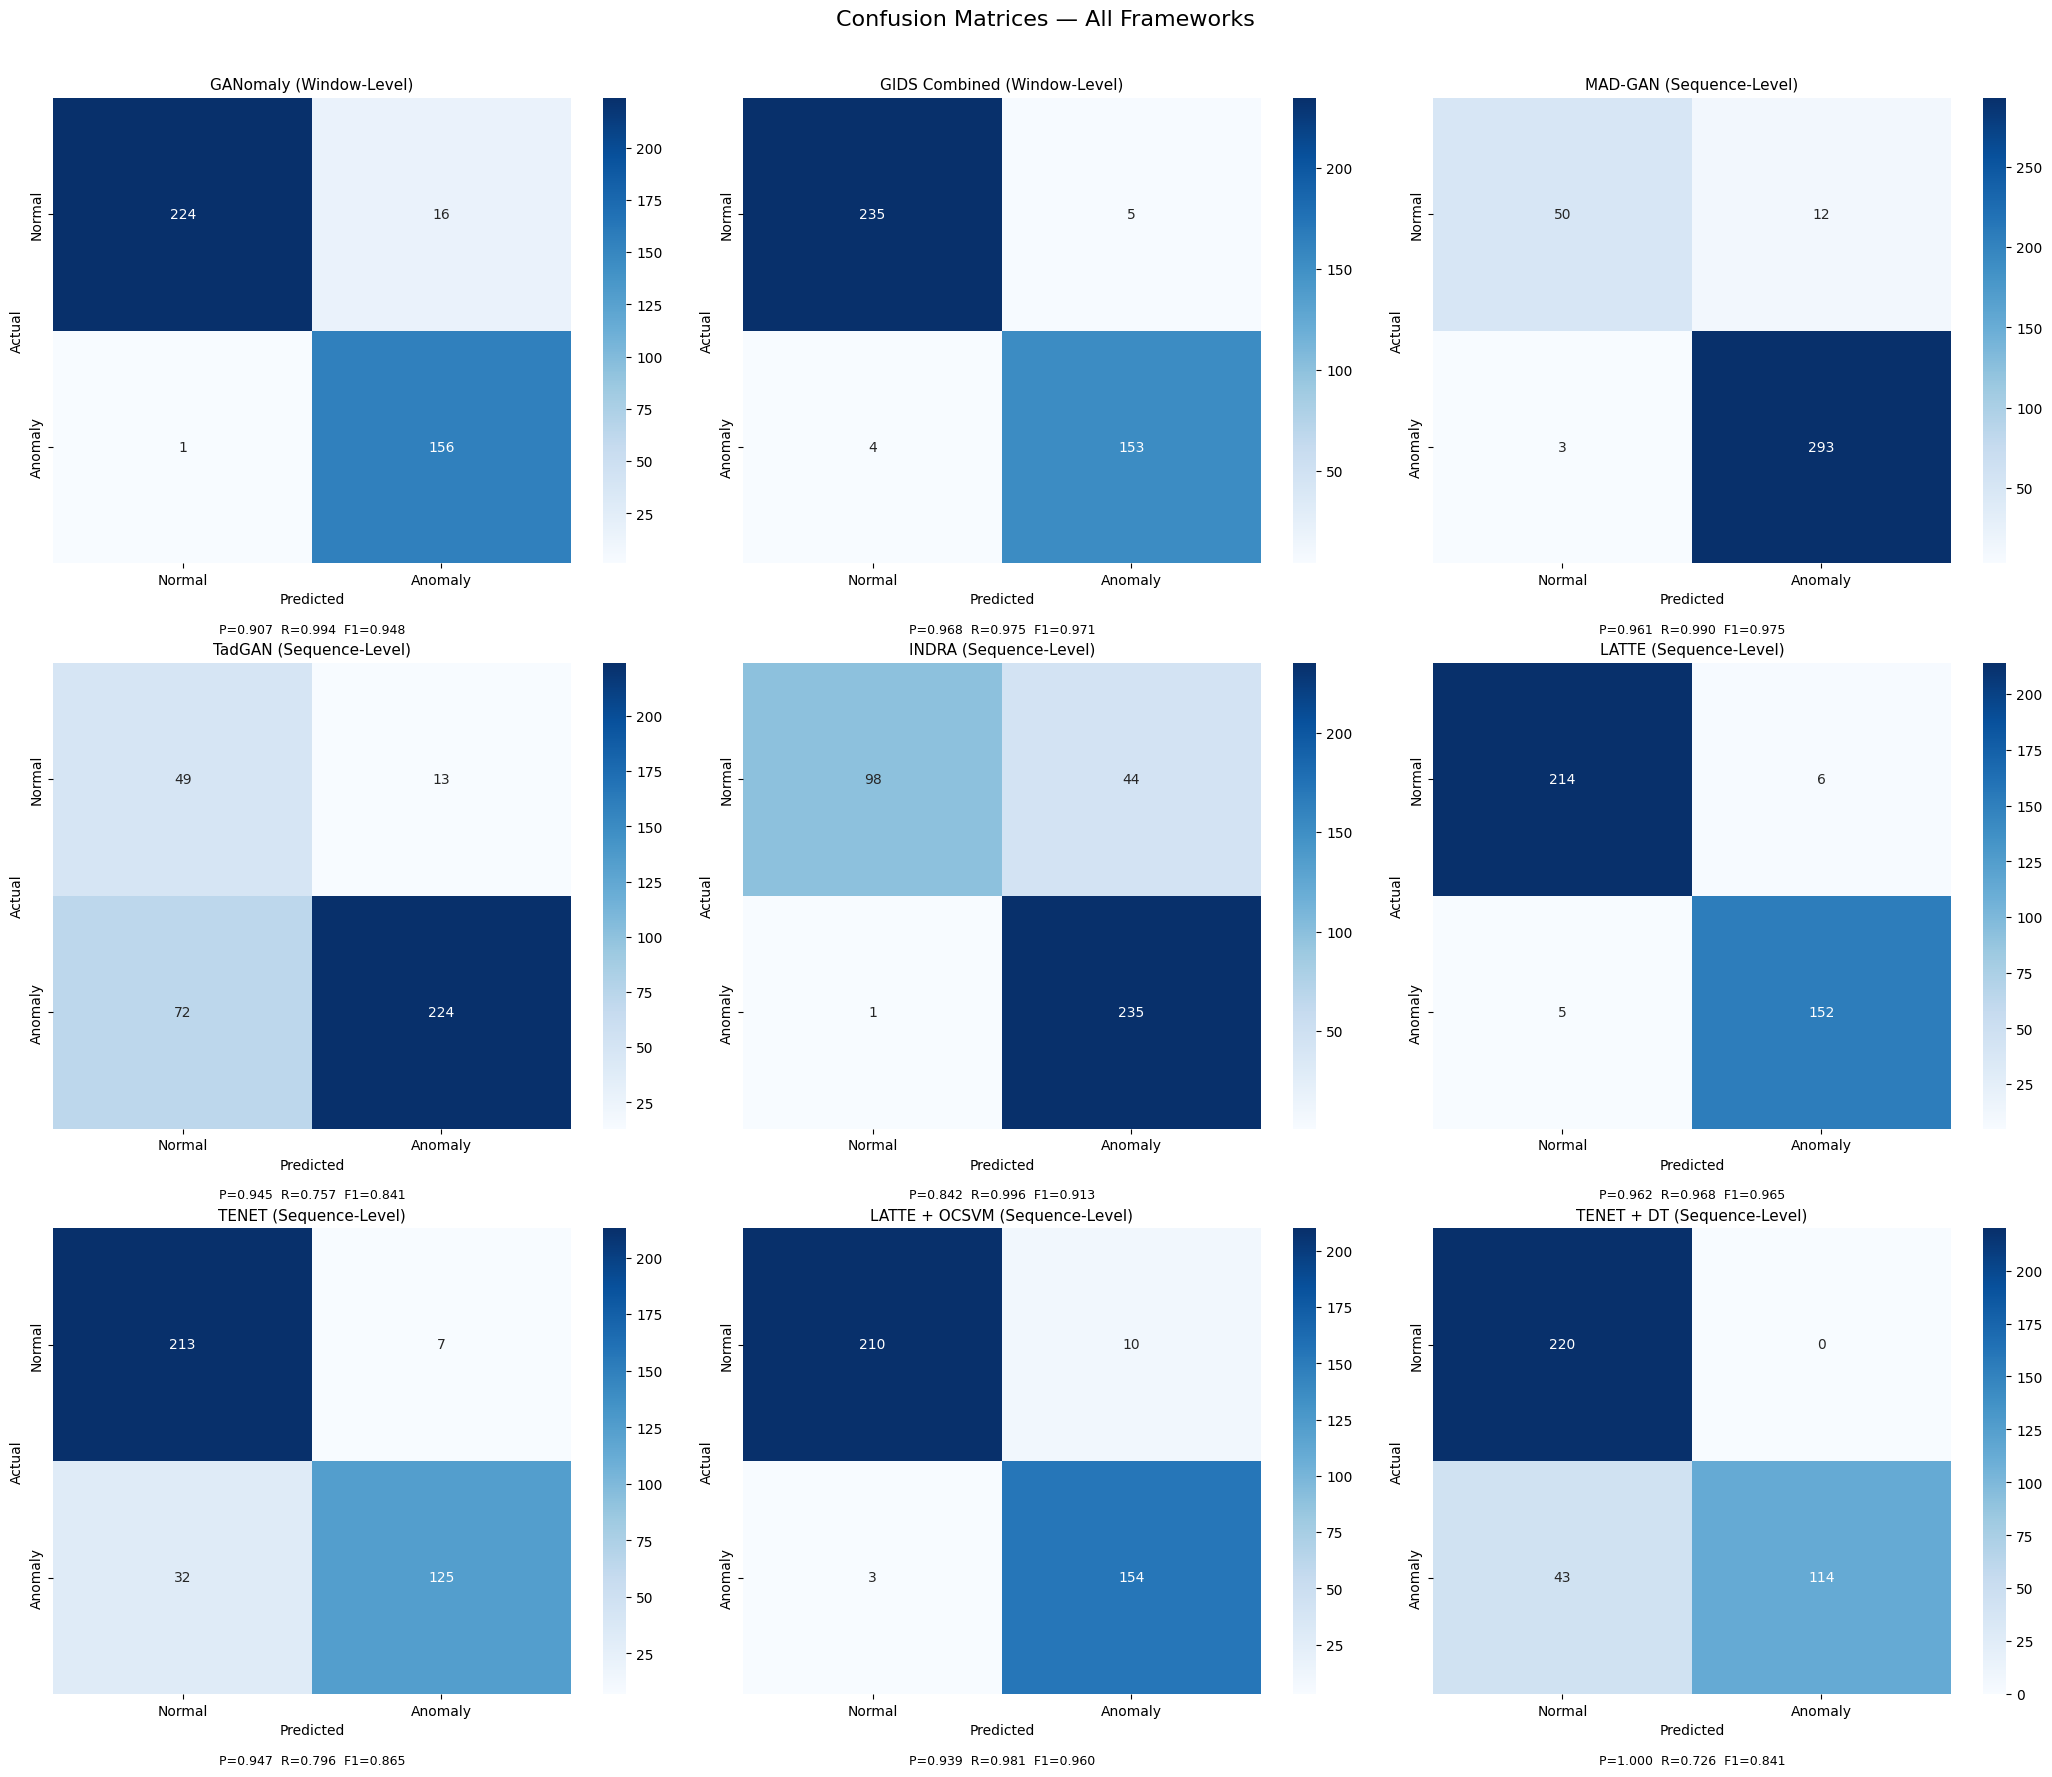

,model,level,TN,FP,FN,TP,precision,recall,f1
0,GANomaly,window,224,16,1,156,0.9070,0.9936,0.9483
1,GIDS Combined,window,235,5,4,153,0.9684,0.9745,0.9714
2,MAD-GAN,sequence,50,12,3,293,0.9607,0.9899,0.9750
3,TadGAN,sequence,49,13,72,224,0.9451,0.7568,0.8405
4,INDRA,sequence,98,44,1,235,0.8423,0.9958,0.9126
5,LATTE,sequence,214,6,5,152,0.9620,0.9682,0.9651
6,TENET,sequence,213,7,32,125,0.9470,0.7962,0.8651
7,LATTE + OCSVM,sequence,210,10,3,154,0.9390,0.9809,0.9595
8,TENET + DT,sequence,220,0,43,114,1.0000,0.7261,0.8413


In [53]:
# =============================================
# Confusion Matrices — All Frameworks
# =============================================

fig, axes = plt.subplots(3, 3, figsize=(21, 18))
fig.suptitle("Confusion Matrices — All Frameworks", fontsize=16)

cm_results = []

def plot_cm_ax(ax, y_true, y_pred, title):
    """Plot confusion matrix heatmap on a given axis and return metrics."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"], cmap="Blues")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    ax.text(0.5, -0.15, f"P={p:.3f}  R={r:.3f}  F1={f:.3f}",
            transform=ax.transAxes, ha="center", fontsize=9)
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "precision": p, "recall": r, "f1": f}

# --- Window-level models ---

# 1. GANomaly
gan_thr_cm = np.percentile(gan_scores_tr_win, THR_PCT)
y_pred_gan_cm = (gan_scores_te_win > gan_thr_cm).astype(int)
m = plot_cm_ax(axes[0,0], y_test_win, y_pred_gan_cm, "GANomaly (Window-Level)")
cm_results.append({"model": "GANomaly", "level": "window", **m})

# 2. GIDS Combined
gids_thr_cm = np.percentile(gids_combined_tr, THR_PCT)
y_pred_gids_cm = (gids_combined_te > gids_thr_cm).astype(int)
m = plot_cm_ax(axes[0,1], y_test_win, y_pred_gids_cm, "GIDS Combined (Window-Level)")
cm_results.append({"model": "GIDS Combined", "level": "window", **m})

# --- Sequence-level models ---

# 3. MAD-GAN
mad_thr_cm = np.percentile(mad_scores_tr, THR_PCT)
y_pred_mad_cm = (mad_scores_te > mad_thr_cm).astype(int)
m = plot_cm_ax(axes[0,2], yte_seq.astype(int), y_pred_mad_cm, "MAD-GAN (Sequence-Level)")
cm_results.append({"model": "MAD-GAN", "level": "sequence", **m})

# 4. TadGAN
tad_thr_cm = np.percentile(tad_scores_tr, THR_PCT)
y_pred_tad_cm = (tad_scores_te > tad_thr_cm).astype(int)
m = plot_cm_ax(axes[1,0], yte_seq.astype(int), y_pred_tad_cm, "TadGAN (Sequence-Level)")
cm_results.append({"model": "TadGAN", "level": "sequence", **m})

# 5. INDRA
indra_thr_cm = np.percentile(scores_tr_i, THR_PCT)
y_pred_indra_cm = (scores_te_i > indra_thr_cm).astype(int)
m = plot_cm_ax(axes[1,1], yte_seq_i, y_pred_indra_cm, "INDRA (Sequence-Level)")
cm_results.append({"model": "INDRA", "level": "sequence", **m})

# 6. LATTE (threshold-only)
latte_thr_cm = np.percentile(latte_tr_scores, THR_PCT)
y_pred_latte_cm = (latte_te_scores > latte_thr_cm).astype(int)
m = plot_cm_ax(axes[1,2], yte_seq_ns, y_pred_latte_cm, "LATTE (Sequence-Level)")
cm_results.append({"model": "LATTE", "level": "sequence", **m})

# 7. TENET (threshold-only)
tenet_thr_cm_val = np.percentile(tenet_tr_scores, THR_PCT)
y_pred_tenet_cm = (tenet_te_scores > tenet_thr_cm_val).astype(int)
m = plot_cm_ax(axes[2,0], yte_seq_ns, y_pred_tenet_cm, "TENET (Sequence-Level)")
cm_results.append({"model": "TENET", "level": "sequence", **m})

# 8. LATTE + OCSVM (pipeline)
_, y_pred_latte_oc_cm = latte_oc.predict(Xte_s_ns, yte_next_s_ns)
m = plot_cm_ax(axes[2,1], yte_seq_ns, y_pred_latte_oc_cm, "LATTE + OCSVM (Sequence-Level)")
cm_results.append({"model": "LATTE + OCSVM", "level": "sequence", **m})

# 9. TENET + DT (pipeline)
_, y_pred_tenet_dt_cm = tenet_dt.predict(Xte_s_ns, yte_next_s_ns)
m = plot_cm_ax(axes[2,2], yte_seq_ns, y_pred_tenet_dt_cm, "TENET + DT (Sequence-Level)")
cm_results.append({"model": "TENET + DT", "level": "sequence", **m})

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Summary table
cm_summary_df = pd.DataFrame(cm_results)
fmt_cols(cm_summary_df, ["precision", "recall", "f1"])

## 14. Final Deployment Comparison

In [54]:
# One-inference functions for all models
def madgan_one():
    _ = madgan_score_one_seq(Gm, Dm, Xte_s[:1], zdim=ZDIM, iters=10, lr_z=0.05, lam=0.5)
def tadgan_one():
    _ = tadgan_score_sequences(En, Gn, Cn, Xte_s[:1], mode="add", alpha=0.5)
def ganomaly_one():
    enc, dec = Enc_gan, Dec_gan
    enc.eval(); dec.eval()
    with torch.no_grad():
        xb = torch.tensor(X_test_win_s[:1], dtype=torch.float32, device=device)
        z = enc(xb); xhat = dec(z); _ = torch.mean(torch.abs(enc(xhat) - z), dim=1)
def gids_one():
    x = torch.tensor(X_test_s_gids[:1], dtype=torch.float32, device=device)
    with torch.no_grad():
        d1_out = D1_gids(x)
        d2_out = D2_gids(x)
def indra_one_fn():
    _ = indra_scores(indra_pt, Xte_seq_i[:1], batch_size=1)
def tenet_thr_one():
    _ = tenet_thr.predict(Xte_s_ns[:1], yte_next_s_ns[:1])
def tenet_dt_one():
    _ = tenet_dt.predict(Xte_s_ns[:1], yte_next_s_ns[:1])
def latte_thr_one():
    _ = latte_thr.predict(Xte_s_ns[:1], yte_next_s_ns[:1])
def latte_oc_one():
    _ = latte_oc.predict(Xte_s_ns[:1], yte_next_s_ns[:1])

workloads = [
    ("GANomaly", ganomaly_one, combined_model_size(Enc_gan, Dec_gan, C_gan)),
    ("GIDS (D1+D2)", gids_one, combined_model_size(D1_gids, D2_gids)),
    ("MAD-GAN", madgan_one, combined_model_size(Gm, Dm)),
    ("TadGAN", tadgan_one, combined_model_size(En, Gn, Cn)),
    ("INDRA", indra_one_fn, model_size_stats(indra_pt)),
    ("LATTE (thr)", latte_thr_one, model_size_stats(latte_model)),
    ("LATTE + OCSVM", latte_oc_one, model_size_stats(latte_model)),
    ("TENET (thr)", tenet_thr_one, model_size_stats(tenet_model)),
    ("TENET + DT", tenet_dt_one, model_size_stats(tenet_model)),
]

t_seq_map = {"GANomaly": 1, "GIDS (D1+D2)": 1, "MAD-GAN": 40, "TadGAN": 40,
             "INDRA": 20, "LATTE (thr)": 20, "LATTE + OCSVM": 20,
             "TENET (thr)": 20, "TENET + DT": 20}

rows = []
for name, fn, size_stats in workloads:
    peak_mem = measure_peak_cuda_mem_mb(fn)
    prof = profile_workload(fn, repeats=300, sample_ms=10)
    row = {"Model": name, **size_stats, "Peak CUDA (MB)": peak_mem, **prof}
    rows.append(row)
    print(f"{name}: {prof['Latency (ms)']:.3f} ms/call, {prof['Energy (J/call)']:.6f} J/call")

resource_df = pd.DataFrame(rows)
resource_df["Latency (ms/window)"] = resource_df.apply(
    lambda r: r["Latency (ms)"] / t_seq_map.get(r["Model"], 1), axis=1)
resource_df["Energy (J/window)"] = resource_df.apply(
    lambda r: r["Energy (J/call)"] / t_seq_map.get(r["Model"], 1), axis=1)

display(resource_df)

GANomaly: 0.389 ms/call, 0.026625 J/call
GIDS (D1+D2): 0.372 ms/call, 0.023396 J/call
MAD-GAN: 261.017 ms/call, 18.859057 J/call
TadGAN: 1.465 ms/call, 0.104655 J/call
INDRA: 1.100 ms/call, 0.079196 J/call
LATTE (thr): 1.233 ms/call, 0.090013 J/call
LATTE + OCSVM: 1.357 ms/call, 0.098913 J/call
TENET (thr): 4.118 ms/call, 0.298269 J/call
TENET + DT: 3.912 ms/call, 0.281447 J/call


,Model,Params,Size (MB),Peak CUDA (MB),Elapsed (s),Latency (ms),Throughput (calls/s),GPU Power Avg (W),GPU Power Peak (W),GPU Util Avg (%),GPU Mem Avg (MB),GPU Mem Peak (MB),CPU Util Avg (%),RSS Peak (MB),Energy Total (J),Energy (J/call),Latency (ms/window),Energy (J/window)
0,GANomaly,1553,0.005924,25.284668,0.116588,0.388627,2573.158454,68.886091,68.947,28.909091,6777.253906,6777.253906,3.527273,2764.269531,7.987608,0.026625,0.388627,0.026625
1,GIDS (D1+D2),19970,0.076180,25.284180,0.111579,0.371931,2688.667736,68.835800,68.851,42.000000,6773.078906,6777.253906,4.330000,2764.269531,7.018718,0.023396,0.371931,0.023396
2,MAD-GAN,108365,0.413380,32.592285,78.304972,261.016572,3.831174,72.252563,73.218,74.757944,6868.472656,6972.011719,4.244290,2765.582031,5657.717174,18.859057,6.525414,0.471476
3,TadGAN,205337,0.783298,57.145996,0.439632,1.465440,682.388677,72.914359,73.325,81.128205,6823.479667,6825.824219,4.210256,2766.707031,31.396533,0.104655,0.036636,0.002616
4,INDRA,64652,0.246628,32.528809,0.330065,1.100216,908.912443,73.379300,73.482,83.133333,6824.880469,6825.824219,4.143333,2766.707031,23.758658,0.079196,0.055011,0.003960
5,LATTE (thr),164236,0.626511,25.311035,0.369947,1.233156,810.927315,73.583176,73.771,78.352941,6822.015395,6822.636719,4.323529,2766.707031,27.003827,0.090013,0.061658,0.004501
6,LATTE + OCSVM,164236,0.626511,25.311035,0.406955,1.356516,737.182829,73.247541,73.771,74.783784,6821.011719,6821.011719,4.156757,2766.707031,29.673819,0.098913,0.067826,0.004946
7,TENET (thr),22728,0.086700,25.287109,1.235454,4.118180,242.825730,72.667591,73.072,74.672727,6821.011719,6821.011719,4.120909,2766.707031,89.480629,0.298269,0.205909,0.014913
8,TENET + DT,22728,0.086700,25.287109,1.173460,3.911532,255.654303,72.405495,72.547,74.679612,6815.040845,6821.011719,4.264078,2766.707031,84.434081,0.281447,0.195577,0.014072
